# ปัจจัยที่สัมพันธ์กับ PM2.5 ในอำเภอหาดใหญ่ (2021–2025)

ข้อมูลรายวันจากสถานี 44T หาดใหญ่ (`assets/MergeData_HatYai_44T_2021-2025_Clean_Seasons_Only.xlsx`) มีทั้งหมด 1,804 วัน

**วัตถุประสงค์**
1. ศึกษาปัจจัยที่สัมพันธ์กับปริมาณฝุ่น PM2.5 ในหาดใหญ่ (ส่วนที่ 3)
2. วิเคราะห์ความสัมพันธ์ระหว่างทิศลม ปริมาณฝน และ PM2.5 รายวัน (ส่วนที่ 4)
3. เปรียบเทียบ PM2.5 ระหว่างวันทำงานกับวันหยุด และระหว่างฤดูมรสุมกับช่วงปกติ (ส่วนที่ 5)

**วิธีใช้:** รันเซลล์จากบนลงล่าง กราฟทุกรูปจะบันทึกไว้ที่ `graph/`

> ผลในนี้เป็น **ความสัมพันธ์** ไม่ได้พิสูจน์เหตุและผล และค่า p-value มีแนวโน้มต่ำกว่าความจริง เพราะค่าฝุ่นของวันที่ติดกันไม่เป็นอิสระต่อกัน

## 0. เตรียม environment

- **รันในเครื่อง:** `uv sync` แล้ว `uv run jupyter lab`
- **Google Colab:** รันเซลล์ถัดไป ระบบจะติดตั้งแพ็กเกจที่ยังขาด แล้วให้อัปโหลดไฟล์ Excel

In [1]:
# ตรวจว่าเปิด notebook บน Google Colab หรือไม่
from pathlib import Path
import importlib.util
import subprocess
import sys

DATA_NAME = "MergeData_HatYai_44T_2021-2025_Clean_Seasons_Only.xlsx"

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

COLAB_DATA_PATH = None
if IN_COLAB:
    required = {"pandas":"pandas", "numpy":"numpy", "matplotlib":"matplotlib", "openpyxl":"openpyxl", "seaborn":"seaborn",
                "scipy":"scipy", "statsmodels":"statsmodels", "sklearn":"scikit-learn"}
    missing = [package for module, package in required.items() if importlib.util.find_spec(module) is None]
    if missing:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

    from google.colab import files
    print(f"เลือกไฟล์ {DATA_NAME} เพื่ออัปโหลด")
    uploaded = files.upload()
    candidates = [name for name in uploaded if name.lower().endswith(".xlsx")]
    if not candidates:
        raise FileNotFoundError("อัปโหลดไฟล์ Excel (.xlsx) เพื่อเริ่มวิเคราะห์")
    chosen = DATA_NAME if DATA_NAME in candidates else candidates[0]
    COLAB_DATA_PATH = Path("/content") / chosen
    print("ใช้ไฟล์:", COLAB_DATA_PATH)
else:
    print("ไม่ได้เปิดใน Colab; ใช้ไฟล์จาก assets/ ของโปรเจกต์")

ไม่ได้เปิดใน Colab; ใช้ไฟล์จาก assets/ ของโปรเจกต์


In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats
from statsmodels.nonparametric.smoothers_lowess import lowess

warnings.filterwarnings("ignore", category=FutureWarning)

# หาไฟล์จาก cwd หรือ parent เพื่อให้รันได้ทั้งจาก root และ notebooks/
_candidates = [Path.cwd() / "assets" / DATA_NAME, Path.cwd().parent / "assets" / DATA_NAME]
DATA_PATH = COLAB_DATA_PATH if IN_COLAB and COLAB_DATA_PATH is not None else next((p for p in _candidates if p.exists()), _candidates[0])
GRAPH_DIR = Path.cwd() / "graph" if IN_COLAB else DATA_PATH.parent.parent / "graph"
GRAPH_DIR.mkdir(parents=True, exist_ok=True)

# ตั้ง seaborn theme ก่อน เพราะ set_theme จะเขียนทับ font และ rcParams อื่น
sns.set_theme(style="whitegrid", context="notebook")

# เลือกฟอนต์ไทยที่ติดตั้งอยู่; ถ้าไม่มีให้ดาวน์โหลด Noto Sans Thai มาใช้เฉพาะกับ Matplotlib
from matplotlib import font_manager
from urllib.request import urlretrieve
_installed_fonts = {f.name for f in font_manager.fontManager.ttflist}
_thai_font_name = next((name for name in ["Noto Sans Thai", "Tahoma", "Leelawadee UI"] if name in _installed_fonts), None)
if _thai_font_name is None:
    _font_dir = Path.home() / ".cache" / "matplotlib" / "thai-fonts"
    _font_dir.mkdir(parents=True, exist_ok=True)
    _font_path = _font_dir / "NotoSansThai.ttf"
    _font_url = "https://raw.githubusercontent.com/google/fonts/main/ofl/notosansthai/NotoSansThai%5Bwdth%2Cwght%5D.ttf"
    try:
        if not _font_path.exists():
            urlretrieve(_font_url, _font_path)
        font_manager.fontManager.addfont(str(_font_path))
        _thai_font_name = font_manager.FontProperties(fname=str(_font_path)).get_name()
    except Exception as exc:
        warnings.warn(f"ดาวน์โหลดฟอนต์ไทยไม่สำเร็จ ({exc}); ตัวอักษรไทยในกราฟอาจแสดงไม่ครบ")
# Noto Sans Thai ไม่มีตัวเลขและอักษรละติน จึงให้ฟอนต์ละตินมาก่อน แล้ว Matplotlib จะ fallback ไปฟอนต์ไทยเองทีละตัวอักษร
_latin_font_name = "Noto Sans" if "Noto Sans" in _installed_fonts else "DejaVu Sans"
FONT_STACK = [_latin_font_name, _thai_font_name] if _thai_font_name else [_latin_font_name]
plt.rcParams["font.family"] = FONT_STACK
plt.rcParams["font.sans-serif"] = FONT_STACK
print("Matplotlib font:", FONT_STACK)

# สีกลางของทุกกราฟ: ตัวอักษรใช้สีเทาเข้ม, grid เป็นเส้นบางสีอ่อน
SURFACE, INK, INK2, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#8a8984", "#e6e5e0"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.linewidth": 0.8, "axes.labelcolor": INK2,
    "axes.titlecolor": INK, "axes.titlesize": 14, "axes.titleweight": "bold", "axes.titlelocation": "left", "axes.titlepad": 12,
    "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "lines.linewidth": 2,
    "axes.unicode_minus": False,   # ฟอนต์ไม่มีเครื่องหมายลบแบบ unicode
})

# categorical 4 สี (ลำดับตายตัว ผ่านการตรวจ colorblind แล้ว) — สีผูกกับกลุ่ม ไม่ผูกกับอันดับ
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
BLUE_RAMP = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
SEQ_CMAP = LinearSegmentedColormap.from_list("seq_blue", BLUE_RAMP)
DIV_CMAP = LinearSegmentedColormap.from_list("div_blue_red", ["#1c5cab", "#6da7ec", "#f0efec", "#ee8c8b", "#b83232"])
NEG, POS = "#2a78d6", "#e34948"   # สหสัมพันธ์ลบ / บวก

SEASON_ORDER = ["NE_Monsoon", "Dry_Season", "Inter_Monsoon", "Transboundary_Haze"]
SEASON_TH = {
    "NE_Monsoon": "มรสุมตะวันออกเฉียงเหนือ\n(16 ต.ค.–ม.ค.)",
    "Dry_Season": "ฤดูแล้ง\n(ก.พ.–เม.ย.)",
    "Inter_Monsoon": "ช่วงเปลี่ยนมรสุม\n(พ.ค.–มิ.ย.)",
    "Transboundary_Haze": "ช่วงหมอกควันข้ามแดน\n(ก.ค.–15 ต.ค.)",
}
SEASON_SHORT = {"NE_Monsoon": "มรสุม ตอ.น.", "Dry_Season": "ฤดูแล้ง", "Inter_Monsoon": "เปลี่ยนมรสุม", "Transboundary_Haze": "หมอกควันข้ามแดน"}
SEASON_COLORS = dict(zip(SEASON_ORDER, SERIES))

DAYTYPE_ORDER = ["วันทำงานปกติ", "วันหยุดสุดสัปดาห์", "วันหยุดราชการ/นักขัตฤกษ์"]
DAYTYPE_COLORS = dict(zip(DAYTYPE_ORDER, SERIES[:3]))

SECTORS = ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]
SECTOR_TH = {"N":"เหนือ", "NE":"ตอ.เฉียงเหนือ", "E":"ตะวันออก", "SE":"ตอ.เฉียงใต้", "S":"ใต้", "SW":"ตต.เฉียงใต้", "W":"ตะวันตก", "NW":"ตต.เฉียงเหนือ"}

# สีระดับ AQI ตามแบบของกรมควบคุมมลพิษ (ปรับเข้มขึ้นเล็กน้อยให้อ่านบนพื้นขาวได้)
AQI_ORDER = ["ดีมาก", "ดี", "ปานกลาง", "เริ่มมีผลกระทบต่อสุขภาพ"]
AQI_COLORS = dict(zip(AQI_ORDER, ["#3bb3e8", "#6fbf4a", "#f2c200", "#f08a00"]))

PM_LABEL = "PM2.5 (มคก./ลบ.ม.)"
TH_STANDARD = 37.5   # มาตรฐาน PM2.5 เฉลี่ย 24 ชม. ของไทย (ปี 2566)

def savefig(fig, filename):
    fig.savefig(GRAPH_DIR / filename, bbox_inches="tight")
    plt.show()
    print(f"บันทึก: {GRAPH_DIR / filename}")

print("ข้อมูล:", DATA_PATH.resolve())
print("โฟลเดอร์รูป:", GRAPH_DIR.resolve())

Matplotlib font: ['Noto Sans', 'Noto Sans Thai']
ข้อมูล: /home/gottagogoon/work/psu/pm-2.5_factors/assets/MergeData_HatYai_44T_2021-2025_Clean_Seasons_Only.xlsx
โฟลเดอร์รูป: /home/gottagogoon/work/psu/pm-2.5_factors/graph


## 1. โหลดข้อมูลและสร้างตัวแปร

เปลี่ยนชื่อคอลัมน์เป็นภาษาอังกฤษสั้น ๆ ตามลำดับคอลัมน์ในไฟล์ แล้วสร้างตัวแปรเพิ่ม

- `rain_lag1` ฝนของเมื่อวาน และ `rain_3d` ฝนสะสม 3 วัน (วันนี้ + 2 วันก่อน) คำนวณเฉพาะเมื่อวันที่ต่อเนื่องกัน เพราะในข้อมูลมีบางวันหายไป
- `wind_sector` แบ่งทิศลม 8 ทิศ (0° = ลมพัดมาจากทิศเหนือ)
- `wind_sin` / `wind_cos` แปลงองศาลมให้ใช้คำนวณสหสัมพันธ์ได้ (sin บวก = ลมมาจากฝั่งตะวันออก, cos บวก = ลมมาจากฝั่งเหนือ)
- `monsoon` แบ่งเป็น **ฤดูมรสุม** (มรสุมตะวันออกเฉียงเหนือ 16 ต.ค.–ม.ค. ซึ่งเป็นช่วงฝนหลักของหาดใหญ่) กับ **ช่วงปกติ** (ฤดูกาลอื่นทั้งหมด)

In [3]:
raw = pd.read_excel(DATA_PATH)
COLS = ["date", "pm25", "aqi", "aqi_level", "year", "month", "wind_max", "wind_gust", "wind_dir", "rain", "day_type", "humidity", "season"]
assert len(raw.columns) == len(COLS), f"คอลัมน์ในไฟล์ไม่ตรงกับที่คาดไว้: {list(raw.columns)}"
display(pd.DataFrame({"ชื่อเดิม": raw.columns, "ชื่อใหม่": COLS}))

df = raw.set_axis(COLS, axis=1).sort_values("date").reset_index(drop=True)
df["date"] = pd.to_datetime(df["date"])

# lag ใช้ได้เฉพาะเมื่อวันก่อนหน้าคือเมื่อวานจริง ๆ
next_day = df.date.diff().dt.days.eq(1)
df["rain_lag1"] = df.rain.shift(1).where(next_day)
df["rain_3d"] = df.rain.rolling(3).sum().where(next_day & next_day.shift(1, fill_value=False))

rad = np.deg2rad(df.wind_dir)
df["wind_sin"], df["wind_cos"] = np.sin(rad), np.cos(rad)
df["wind_sector"] = pd.Categorical(np.array(SECTORS)[(((df.wind_dir + 22.5) % 360) // 45).astype(int)], categories=SECTORS, ordered=True)

RAIN_BINS = ["ไม่มีฝน", "0.1–5 มม.", "5–20 มม.", "> 20 มม."]
df["rain_bin"] = pd.cut(df.rain, [-np.inf, 0, 5, 20, np.inf], labels=RAIN_BINS)
df["season"] = pd.Categorical(df.season, categories=SEASON_ORDER, ordered=True)
df["day_type"] = pd.Categorical(df.day_type, categories=DAYTYPE_ORDER, ordered=True)
df["aqi_level"] = pd.Categorical(df.aqi_level, categories=AQI_ORDER, ordered=True)
df["monsoon"] = pd.Categorical(np.where(df.season.eq("NE_Monsoon"), "ฤดูมรสุม", "ช่วงปกติ"), categories=["ฤดูมรสุม", "ช่วงปกติ"])
df["pm25_roll30"] = df.set_index("date").pm25.rolling("30D", min_periods=20).mean().to_numpy()

gaps = df.loc[df.date.diff().dt.days.gt(1), "date"]
print(f"{len(df):,} วัน ตั้งแต่ {df.date.min():%Y-%m-%d} ถึง {df.date.max():%Y-%m-%d}; ค่าว่างทั้งหมด {int(raw.isna().sum().sum())} ช่อง")
print("วันที่ที่มีช่องว่างก่อนหน้า:", ", ".join(f"{d:%Y-%m-%d}" for d in gaps))
display(df.groupby("season", observed=True).date.agg(["min", "max", "count"]).rename(index=SEASON_SHORT))
display(df[["pm25", "wind_max", "wind_gust", "rain", "humidity"]].describe().T.round(2))

,ชื่อเดิม,ชื่อใหม่
0,วันที่,date
1,PM2.5 (มคก./ลบ.ม.),pm25
2,AQI,aqi
3,ระดับคุณภาพอากาศ,aqi_level
4,ปี,year
5,เดือน,month
6,ลมสูงสุด (km/h),wind_max
7,ลมกระโชก (km/h),wind_gust
8,ทิศลม (°),wind_dir
9,ปริมาณน้ำฝน (มม.),rain


1,804 วัน ตั้งแต่ 2021-01-01 ถึง 2025-12-31; ค่าว่างทั้งหมด 0 ช่อง
วันที่ที่มีช่องว่างก่อนหน้า: 2022-02-04, 2022-03-16, 2022-03-30, 2023-01-19, 2023-02-10, 2024-10-06, 2025-09-19, 2025-12-07


,min,max,count
season,,,
มรสุม ตอ.น.,2021-01-01,2025-12-31,526
ฤดูแล้ง,2021-02-01,2025-04-30,442
เปลี่ยนมรสุม,2021-05-01,2025-06-30,305
หมอกควันข้ามแดน,2021-07-01,2025-10-15,531


,count,mean,std,min,25%,50%,75%,max
pm25,1804.0,14.93,5.26,5.50,11.3,14.30,18.00,44.40
wind_max,1804.0,16.30,4.83,5.90,12.5,15.70,19.50,33.80
wind_gust,1804.0,36.51,8.90,14.00,29.5,35.30,42.50,70.60
rain,1804.0,5.86,16.47,0.00,0.0,0.20,4.60,370.20
humidity,1804.0,80.31,5.51,62.63,76.5,79.88,83.75,97.88


## 2. ภาพรวม PM2.5

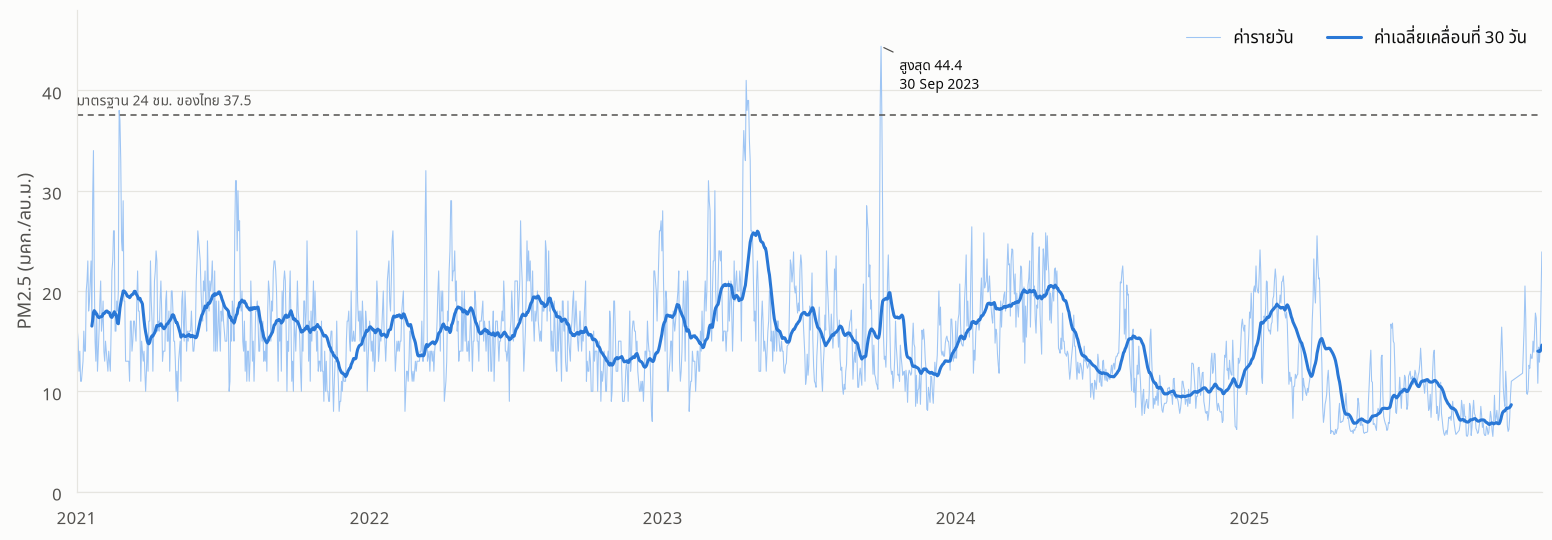

บันทึก: /home/gottagogoon/work/psu/pm-2.5_factors/graph/01_pm25_timeseries.png


,mean,median,count
year,,,
2021,16.68,16.0,365
2022,15.92,15.0,362
2023,16.61,15.2,363
2024,14.30,13.2,365
2025,10.99,9.8,349


วันที่เกินมาตรฐาน 37.5: 7 วัน -> 2021-02-23, 2023-04-15, 2023-04-16, 2023-04-17, 2023-04-18, 2023-09-29, 2023-09-30


In [4]:
fig, ax = plt.subplots(figsize=(14, 4.8), layout="constrained")
ax.plot(df.date, df.pm25, color="#9ec5f4", lw=0.7, label="ค่ารายวัน")
ax.plot(df.date, df.pm25_roll30, color=SERIES[0], lw=2, label="ค่าเฉลี่ยเคลื่อนที่ 30 วัน")
ax.axhline(TH_STANDARD, color=INK2, lw=1, ls=(0, (4, 3)))
ax.text(df.date.min(), TH_STANDARD + 0.6, f"มาตรฐาน 24 ชม. ของไทย {TH_STANDARD}", fontsize=9, color=INK2, va="bottom")
peak = df.loc[df.pm25.idxmax()]
ax.annotate(f"สูงสุด {peak.pm25:.1f}\n{peak.date:%d %b %Y}", (peak.date, peak.pm25), xytext=(12, -6), textcoords="offset points",
            fontsize=9, color=INK, va="top", arrowprops={"arrowstyle": "-", "color": INK2, "lw": 0.8})
ax.set(ylabel=PM_LABEL, ylim=(0, 48), xlim=(df.date.min(), df.date.max()))
ax.xaxis.set_major_locator(mdates.YearLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.grid(axis="x", visible=False)
ax.legend(loc="upper right", ncol=2)
savefig(fig, "01_pm25_timeseries.png")

annual = df.groupby("year").pm25.agg(["mean", "median", "count"]).round(2)
display(annual)
over = df[df.pm25 > TH_STANDARD]
print(f"วันที่เกินมาตรฐาน {TH_STANDARD}: {len(over)} วัน ->", ", ".join(f"{d:%Y-%m-%d}" for d in over.date))

**อ่านกราฟ:** ค่าเฉลี่ยรายปีลดจาก 16.7 (2021) เหลือ 11.0 (2025) และตลอด 5 ปีมีเพียง 7 วันที่เกินมาตรฐาน 37.5 ทุกวันอยู่ในสองช่วงนี้
- ฤดูแล้ง: 23 ก.พ. 2021 และ 15–18 เม.ย. 2023
- ช่วงหมอกควันข้ามแดน: 29–30 ก.ย. 2023 ค่าสูงสุดของชุดข้อมูลคือ 44.4 ในวันที่ 30 ก.ย. 2023

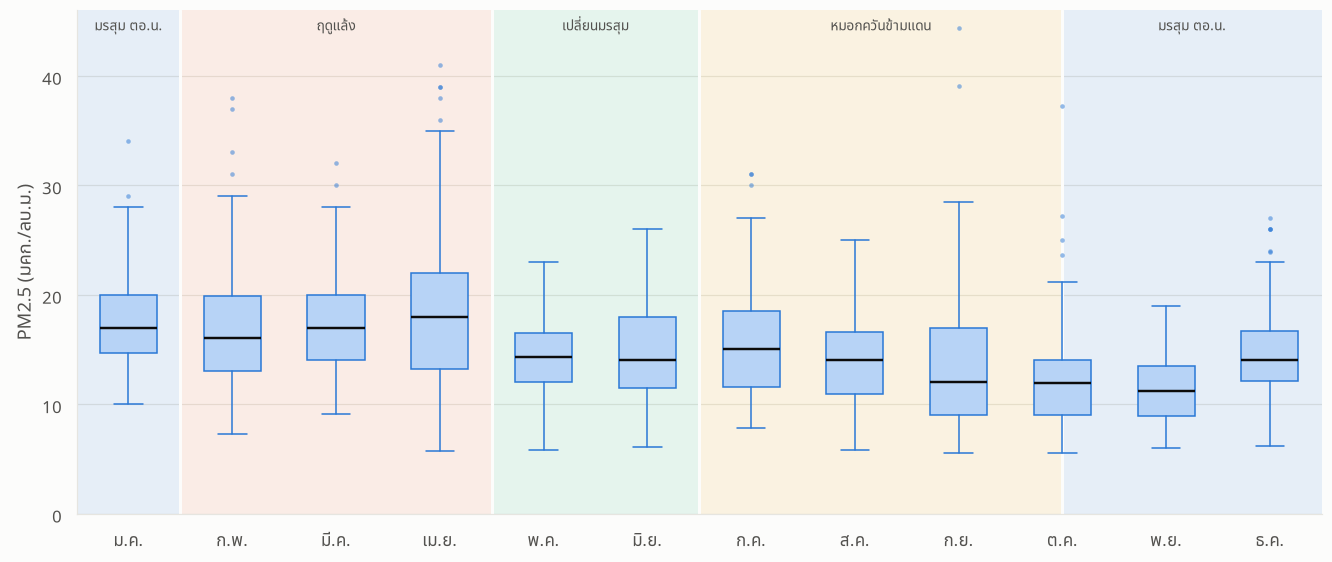

บันทึก: /home/gottagogoon/work/psu/pm-2.5_factors/graph/02_pm25_by_month.png


In [5]:
# กล่องรายเดือน + แถบพื้นหลังบอกฤดู (ต.ค. แบ่งครึ่งเดือนระหว่างหมอกควันกับมรสุม)
SEASON_SPANS = [("NE_Monsoon", 0.5, 1.5), ("Dry_Season", 1.5, 4.5), ("Inter_Monsoon", 4.5, 6.5),
                ("Transboundary_Haze", 6.5, 10.0), ("NE_Monsoon", 10.0, 12.5)]
fig, ax = plt.subplots(figsize=(12, 5), layout="constrained")
for s, x0, x1 in SEASON_SPANS:
    ax.axvspan(x0, x1, color=SEASON_COLORS[s], alpha=0.10, lw=0)
    ax.text((x0 + x1) / 2, 45.5, SEASON_SHORT[s], ha="center", va="top", fontsize=9, color=INK2)
for x in [1.5, 4.5, 6.5, 10.0]:
    ax.axvline(x, color=SURFACE, lw=2)
box_data = [df.loc[df.month.eq(m), "pm25"] for m in range(1, 13)]
ax.boxplot(box_data, positions=range(1, 13), widths=0.55, patch_artist=True, showfliers=True,
           boxprops={"facecolor": "#b7d3f6", "edgecolor": SERIES[0], "lw": 1},
           medianprops={"color": INK, "lw": 1.6}, whiskerprops={"color": SERIES[0], "lw": 1}, capprops={"color": SERIES[0], "lw": 1},
           flierprops={"marker": "o", "ms": 3, "mfc": SERIES[0], "mec": "none", "alpha": 0.5})
ax.set_xticks(range(1, 13), ["ม.ค.", "ก.พ.", "มี.ค.", "เม.ย.", "พ.ค.", "มิ.ย.", "ก.ค.", "ส.ค.", "ก.ย.", "ต.ค.", "พ.ย.", "ธ.ค."])
ax.set(xlim=(0.5, 12.5), ylim=(0, 46), ylabel=PM_LABEL)
ax.grid(axis="x", visible=False)
savefig(fig, "02_pm25_by_month.png")

**อ่านกราฟ:** ฝุ่นสูงช่วง ม.ค.–เม.ย. (มัธยฐานประมาณ 16–18) และต่ำสุดช่วง ต.ค.–พ.ย. (ประมาณ 11–12) ฤดูกาลจึงเป็นกรอบใหญ่ที่ปัจจัยอื่นซ้อนอยู่ข้างใน

## 3. วัตถุประสงค์ 1: ปัจจัยที่สัมพันธ์กับ PM2.5

ใช้ **Spearman correlation** เพราะฝนมีการกระจายเบ้มาก (ครึ่งหนึ่งของวันไม่มีฝน) และความสัมพันธ์อาจไม่เป็นเส้นตรง ค่า r อยู่ระหว่าง −1 ถึง 1 ค่าลบแปลว่าตัวแปรนั้นสูงขึ้นแล้วฝุ่นลดลง

,ปัจจัย,Spearman r,p-value,n
7,ฝนสะสม 3 วัน,-0.3927,0.0000,1786
6,ฝนเมื่อวาน,-0.3542,0.0000,1795
5,ฝนวันนี้,-0.3018,0.0000,1804
4,ความชื้นสัมพัทธ์,-0.2695,0.0000,1804
2,ความเร็วลมสูงสุด,-0.0936,0.0001,1804
1,ลมกระโชก,-0.0636,0.0069,1804
0,ทิศลม (+ = มาจากเหนือ),0.0335,0.1545,1804
3,ทิศลม (+ = มาจากตะวันออก),0.1774,0.0000,1804


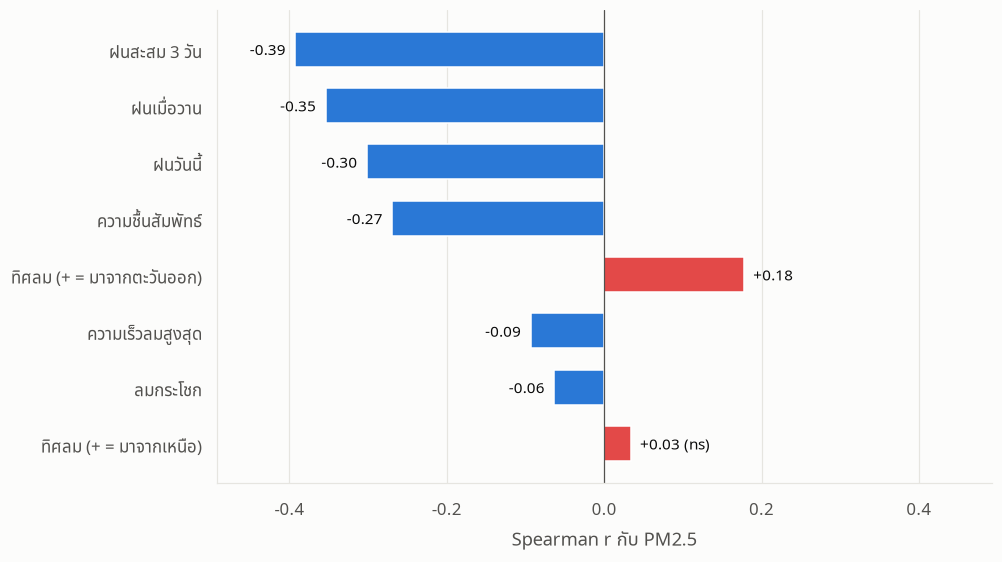

บันทึก: /home/gottagogoon/work/psu/pm-2.5_factors/graph/03_factor_correlations.png


In [6]:
FACTORS = {
    "rain": "ฝนวันนี้", "rain_lag1": "ฝนเมื่อวาน", "rain_3d": "ฝนสะสม 3 วัน",
    "wind_max": "ความเร็วลมสูงสุด", "wind_gust": "ลมกระโชก", "humidity": "ความชื้นสัมพัทธ์",
    "wind_sin": "ทิศลม (+ = มาจากตะวันออก)", "wind_cos": "ทิศลม (+ = มาจากเหนือ)",
}
rows = []
for col, label in FACTORS.items():
    d = df[["pm25", col]].dropna()
    r, p = stats.spearmanr(d.pm25, d[col])
    rows.append({"ปัจจัย": label, "col": col, "Spearman r": r, "p-value": p, "n": len(d)})
cor_table = pd.DataFrame(rows).sort_values("Spearman r", key=np.abs).reset_index(drop=True)
display(cor_table.drop(columns="col").sort_values("Spearman r").round(4))

fig, ax = plt.subplots(figsize=(9, 5), layout="constrained")
colors = [NEG if r < 0 else POS for r in cor_table["Spearman r"]]
ax.barh(cor_table["ปัจจัย"], cor_table["Spearman r"], color=colors, height=0.62)
for i, (r, p) in enumerate(zip(cor_table["Spearman r"], cor_table["p-value"])):
    star = "" if p < 0.05 else " (ns)"
    ax.text(r + (0.012 if r >= 0 else -0.012), i, f"{r:+.2f}{star}", va="center", ha="left" if r >= 0 else "right", fontsize=10, color=INK)
ax.axvline(0, color=INK2, lw=0.8)
lim = cor_table["Spearman r"].abs().max() + 0.1
ax.set(xlim=(-lim, lim), xlabel="Spearman r กับ PM2.5")
ax.grid(axis="y", visible=False)
savefig(fig, "03_factor_correlations.png")

**อ่านกราฟ:**
- **ฝน** สัมพันธ์กับฝุ่นมากที่สุด โดยฝนสะสม 3 วัน (−0.39) และฝนเมื่อวาน (−0.35) สัมพันธ์แรงกว่าฝนวันนี้ (−0.30)
- **ความชื้น** มาเป็นอันดับถัดไป (−0.27)
- **ทิศลม** จากฝั่งตะวันออกมาพร้อมฝุ่นมากขึ้นเล็กน้อย (+0.18)
- **ความเร็วลม** แทบไม่สัมพันธ์ (−0.09)
- ไม่มีปัจจัยใดสูงเกิน |0.4| แปลว่าไม่มีปัจจัยเดียวที่อธิบายฝุ่นได้ทั้งหมด

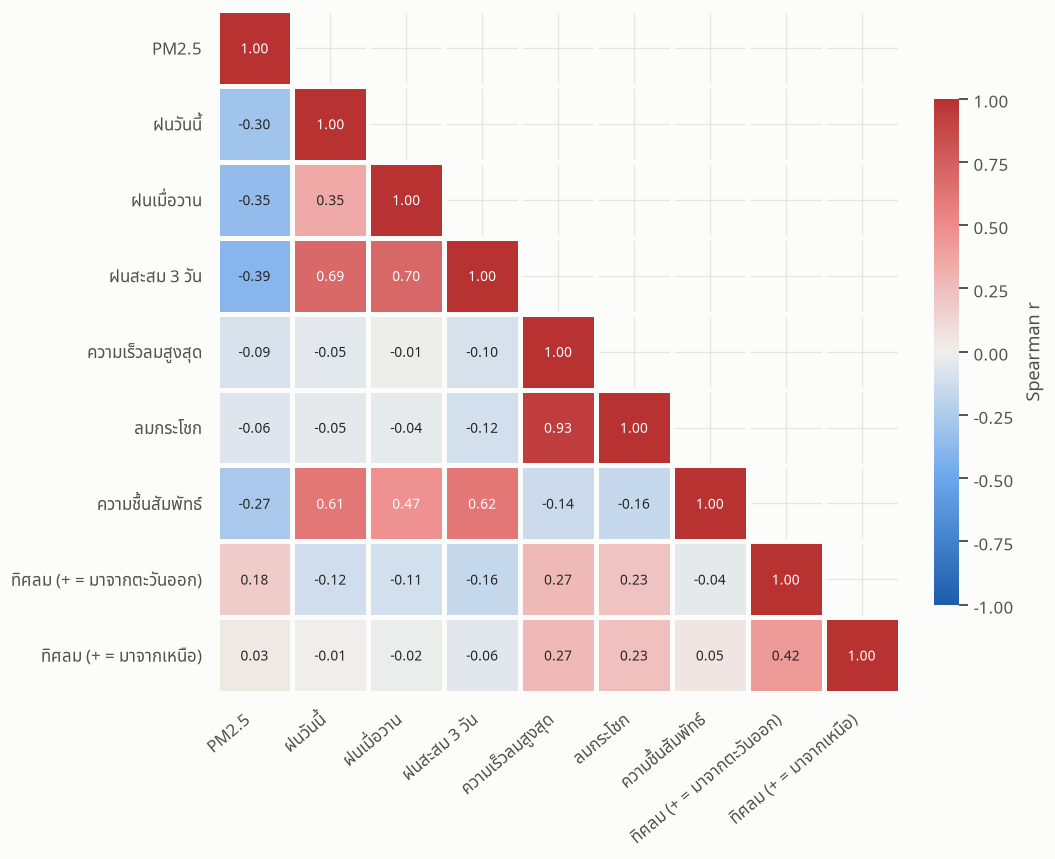

บันทึก: /home/gottagogoon/work/psu/pm-2.5_factors/graph/04_correlation_matrix.png


In [7]:
# ความสัมพันธ์ระหว่างปัจจัยด้วยกันเอง: ใช้ดูว่าตัวแปรไหนซ้ำซ้อนกัน
corr_cols = ["pm25", *FACTORS]
corr = df[corr_cols].corr(method="spearman").rename(index={"pm25": "PM2.5", **FACTORS}, columns={"pm25": "PM2.5", **FACTORS})
fig, ax = plt.subplots(figsize=(9.5, 8), layout="constrained")
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool), k=1), annot=True, fmt=".2f", annot_kws={"fontsize": 9},
            cmap=DIV_CMAP, vmin=-1, vmax=1, center=0, square=True, linewidths=2, linecolor=SURFACE,
            cbar_kws={"label": "Spearman r", "shrink": 0.7}, ax=ax)
ax.tick_params(axis="x", rotation=40); plt.setp(ax.get_xticklabels(), ha="right")
savefig(fig, "04_correlation_matrix.png")

**อ่านกราฟ:** ฝนกับความชื้นสัมพันธ์กันเอง (0.61) ส่วนลมสูงสุดกับลมกระโชกแทบเป็นข้อมูลเดียวกัน (0.93) ผลของความชื้นจึงซ้อนกับผลของฝนบางส่วน

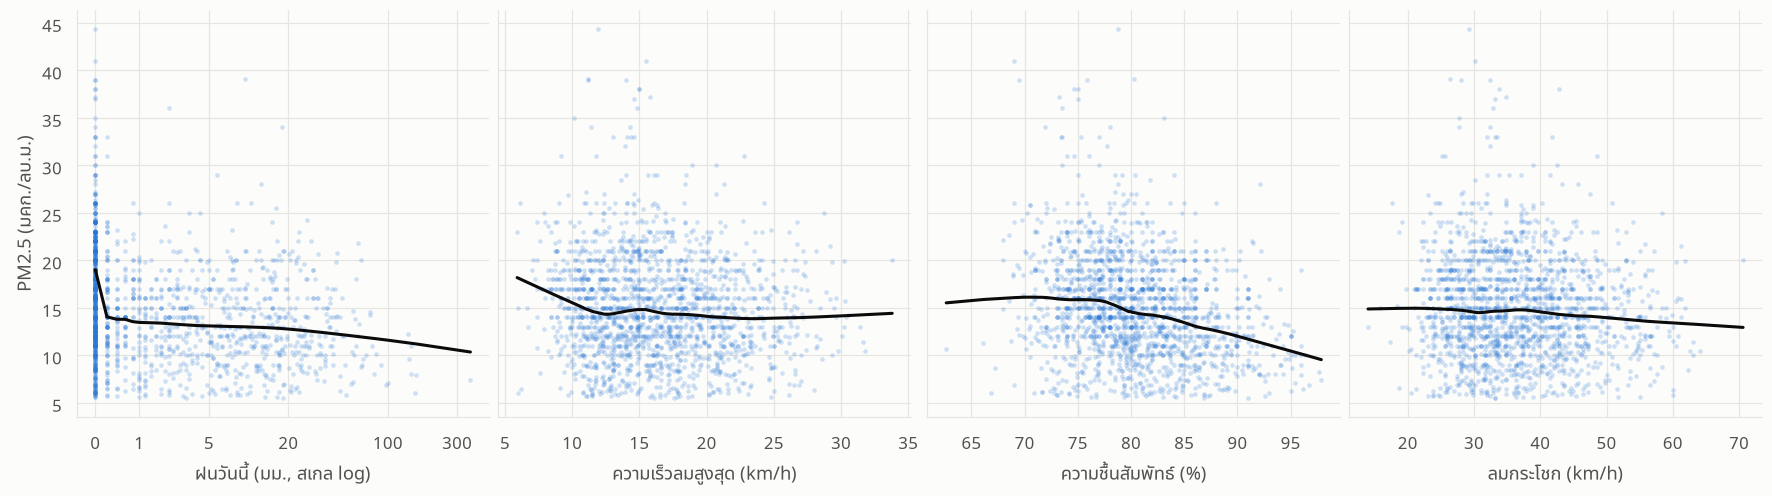

บันทึก: /home/gottagogoon/work/psu/pm-2.5_factors/graph/05_factor_scatter.png


In [8]:
# scatter แต่ละปัจจัย + เส้น LOWESS ให้เห็นรูปร่างความสัมพันธ์ที่ไม่ใช่เส้นตรง
panels = [("rain", "ฝนวันนี้ (มม., สเกล log)"), ("wind_max", "ความเร็วลมสูงสุด (km/h)"),
          ("humidity", "ความชื้นสัมพัทธ์ (%)"), ("wind_gust", "ลมกระโชก (km/h)")]
fig, axes = plt.subplots(1, 4, figsize=(16, 4.4), sharey=True, layout="constrained")
for ax, (col, label) in zip(axes, panels):
    x = np.log1p(df[col]) if col == "rain" else df[col]
    ax.scatter(x, df.pm25, s=9, color=SERIES[0], alpha=0.22, lw=0)
    with warnings.catch_warnings():   # ฝน = 0 ซ้ำกันเยอะ ทำให้ LOWESS เตือนหารศูนย์
        warnings.simplefilter("ignore", RuntimeWarning)
        fit = lowess(df.pm25, x, frac=0.4)
    ax.plot(fit[:, 0], fit[:, 1], color=INK, lw=2)
    ax.set_xlabel(label)
    if col == "rain":
        ticks = [0, 1, 5, 20, 100, 300]
        ax.set_xticks(np.log1p(ticks), ticks)
axes[0].set_ylabel(PM_LABEL)
savefig(fig, "05_factor_scatter.png")

**อ่านกราฟ:**
- **ฝน** ความสัมพันธ์ไม่เป็นเส้นตรง ฝุ่นลดลงมากที่สุดระหว่าง "ไม่มีฝน" กับ "ฝนเล็กน้อย" หลังจากนั้นเส้นค่อนข้างราบ
- **ความชื้น** ฝุ่นเริ่มลดเมื่อความชื้นเกินประมาณ 78%
- **ลม** ฝุ่นสูงขึ้นเฉพาะวันที่ลมอ่อนมาก (ต่ำกว่า 10 km/h) มัธยฐาน 16.5 เทียบกับ 14.0–14.7 ในวันลมแรงกว่า

## 4. วัตถุประสงค์ 2: ทิศลม ปริมาณฝน กับ PM2.5 รายวัน

### 4.1 ทิศลม

,mean,median,count,share_%
wind_sector,,,,
เหนือ,13.40,13.0,37,2.05
ตอ.เฉียงเหนือ,15.53,15.0,170,9.42
ตะวันออก,15.63,15.0,668,37.03
ตอ.เฉียงใต้,15.53,15.0,73,4.05
ใต้,17.03,17.0,93,5.16
ตต.เฉียงใต้,14.22,14.0,566,31.37
ตะวันตก,13.27,13.0,165,9.15
ตต.เฉียงเหนือ,12.70,11.7,32,1.77


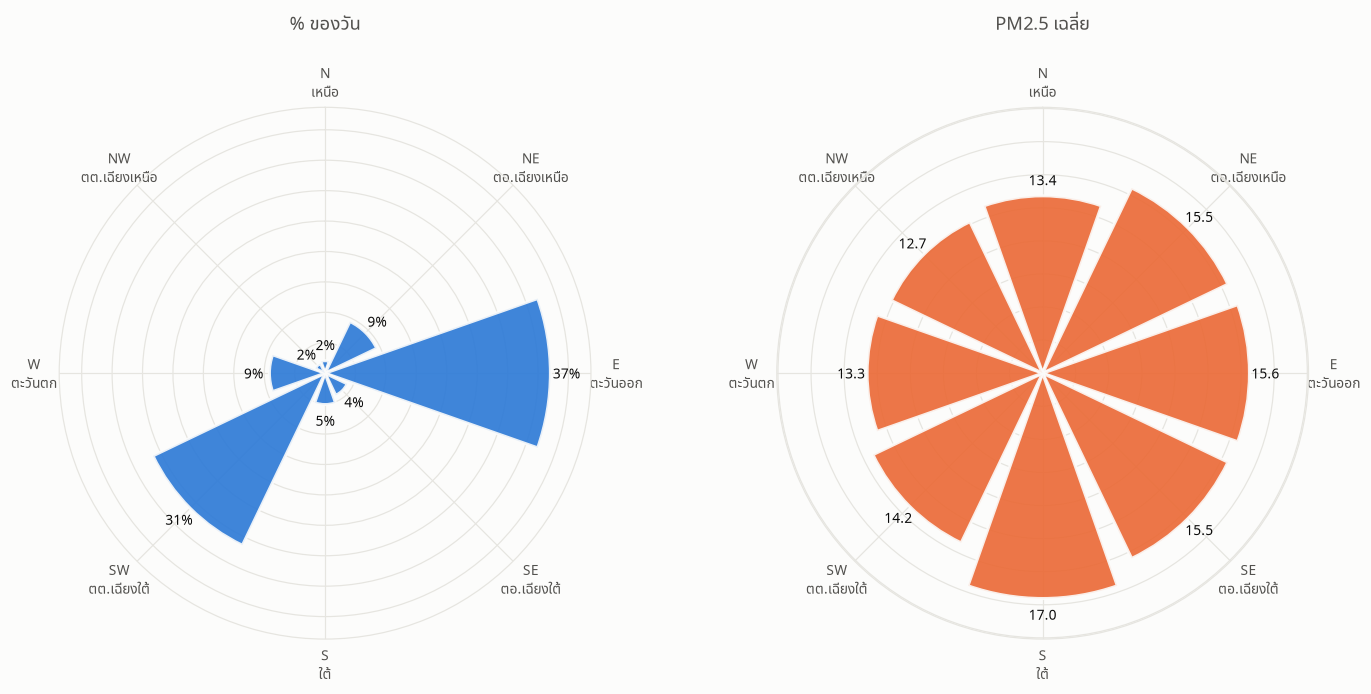

บันทึก: /home/gottagogoon/work/psu/pm-2.5_factors/graph/06_wind_direction_polar.png


In [9]:
sector_stats = df.groupby("wind_sector", observed=False).pm25.agg(["mean", "median", "count"])
sector_stats["share_%"] = 100 * sector_stats["count"] / len(df)
display(sector_stats.rename(index=SECTOR_TH).round(2))

theta = np.deg2rad(np.arange(0, 360, 45))
width = np.deg2rad(45) * 0.86
fig, axes = plt.subplots(1, 2, figsize=(13, 6.2), subplot_kw={"projection": "polar"}, layout="constrained")
for ax, col, title, fmt in [(axes[0], "share_%", "% ของวัน", "{:.0f}%"),
                            (axes[1], "mean", "PM2.5 เฉลี่ย", "{:.1f}")]:
    vals = sector_stats[col].to_numpy()
    ax.bar(theta, vals, width=width, color=SERIES[0] if col == "share_%" else SERIES[1], alpha=0.9, edgecolor=SURFACE, lw=2)
    ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
    ax.set_xticks(theta, [f"{s}\n{SECTOR_TH[s]}" for s in SECTORS], fontsize=9)
    ax.set_yticklabels([])   # ค่าเขียนไว้ที่ปลายแท่งแล้ว
    ax.grid(color=GRID, lw=0.8)
    ax.spines["polar"].set_color(GRID)
    top = vals.max() * 1.18
    ax.set_ylim(0, top)
    for t, v, n in zip(theta, vals, sector_stats["count"]):
        ax.text(t, v + top * 0.06, fmt.format(v), ha="center", va="center", fontsize=9, color=INK)
    ax.set_title(title, loc="center", pad=22, fontsize=12, fontweight="normal", color=INK2)
savefig(fig, "06_wind_direction_polar.png")

**อ่านกราฟ:** ลมที่หาดใหญ่มาจากสองทิศหลัก คือ **ตะวันออก (37%)** และ **ตะวันตกเฉียงใต้ (31%)**
- ลมจากฝั่งตะวันออกและใต้ (NE, E, SE, S) ฝุ่นเฉลี่ย 15.5–17.0
- ลมจากฝั่งตะวันตก (SW, W, NW) ฝุ่นเฉลี่ยต่ำกว่า คือ 12.7–14.2

Kruskal–Wallis (ทิศลม): H = 72.6, p = 4.4e-13


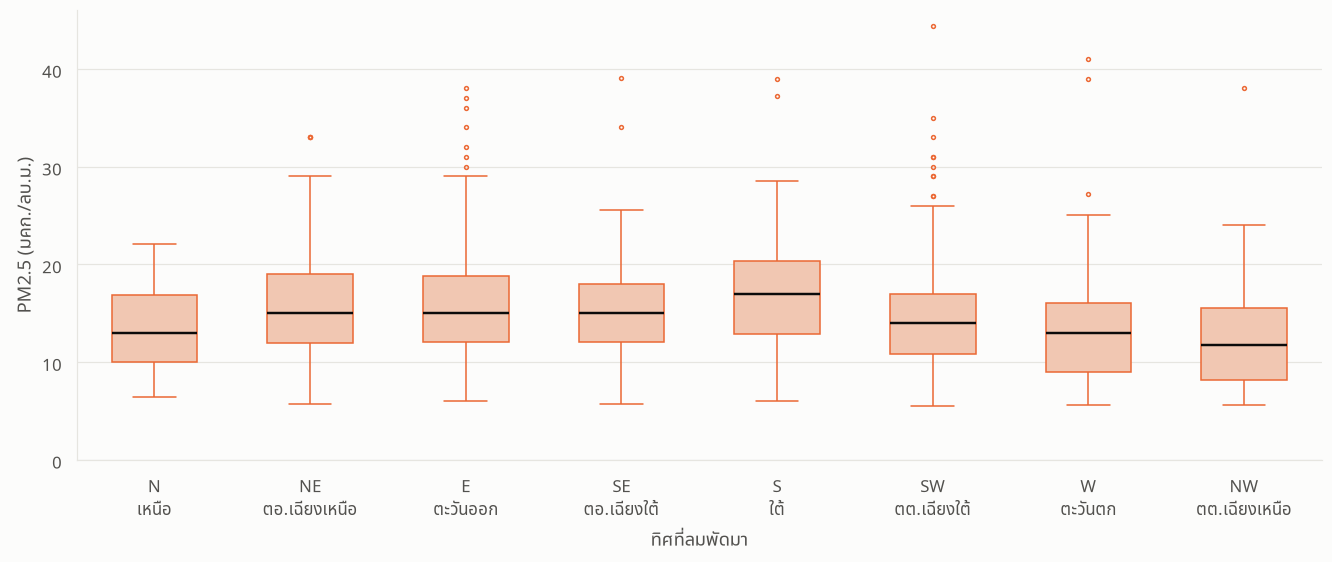

บันทึก: /home/gottagogoon/work/psu/pm-2.5_factors/graph/07_wind_direction_boxplot.png


In [10]:
# กล่อง PM2.5 แยกตามทิศลม เรียงตามเข็มนาฬิกา
fig, ax = plt.subplots(figsize=(12, 5), layout="constrained")
sns.boxplot(data=df, x="wind_sector", y="pm25", order=SECTORS, color="#fbc3a8", width=0.55, linewidth=1,
            linecolor=SERIES[1], fliersize=2.5, medianprops={"color": INK, "lw": 1.6}, ax=ax)
ax.set_xticks(range(len(SECTORS)), [f"{s}\n{SECTOR_TH[s]}" for s in SECTORS])
ax.set(xlabel="ทิศที่ลมพัดมา", ylabel=PM_LABEL, ylim=(0, 46))
ax.grid(axis="x", visible=False)
kw = stats.kruskal(*[g.pm25 for _, g in df.groupby("wind_sector", observed=True)])
print(f"Kruskal–Wallis (ทิศลม): H = {kw.statistic:.1f}, p = {kw.pvalue:.1e}")
savefig(fig, "07_wind_direction_boxplot.png")

,วันอื่น ๆ,"วันฝุ่นสูง (ตั้งแต่ 21.2 ขึ้นไป, 10% บนสุด)"
wind_sector,,
เหนือ,2.2,0.6
ตอ.เฉียงเหนือ,9.1,12.7
ตะวันออก,36.5,41.4
ตอ.เฉียงใต้,4.0,4.4
ใต้,4.6,9.9
ตต.เฉียงใต้,32.2,24.3
ตะวันตก,9.6,5.5
ตต.เฉียงเหนือ,1.8,1.1


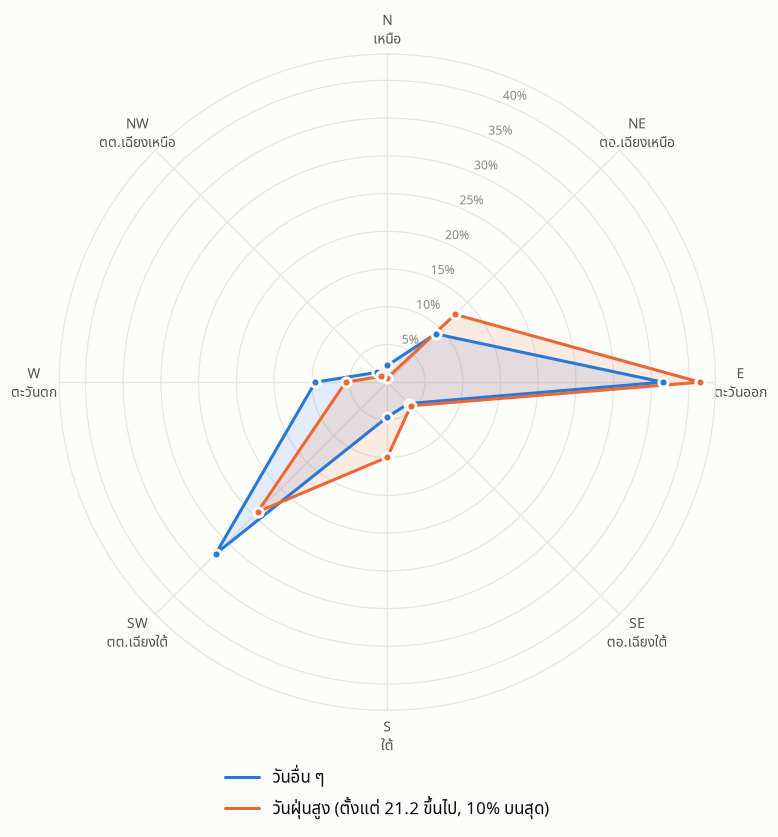

บันทึก: /home/gottagogoon/work/psu/pm-2.5_factors/graph/08_windrose_high_vs_normal.png


In [11]:
# วันที่ฝุ่นสูง (10% บนสุด) ลมมาจากทิศไหนเมื่อเทียบกับวันอื่น
q90 = df.pm25.quantile(0.90)
share = (pd.crosstab(df.wind_sector, df.pm25 >= q90, normalize="columns") * 100).reindex(SECTORS)
share.columns = ["วันอื่น ๆ", f"วันฝุ่นสูง (ตั้งแต่ {q90:.1f} ขึ้นไป, 10% บนสุด)"]
display(share.rename(index=SECTOR_TH).round(1))

fig, ax = plt.subplots(figsize=(7.5, 7.5), subplot_kw={"projection": "polar"}, layout="constrained")
closed = np.append(theta, theta[0])
for col, color in zip(share.columns, [SERIES[0], SERIES[1]]):
    v = np.append(share[col].to_numpy(), share[col].iloc[0])
    ax.plot(closed, v, color=color, lw=2, label=col)
    ax.fill(closed, v, color=color, alpha=0.12)
    ax.scatter(theta, share[col], s=36, color=color, edgecolor=SURFACE, lw=2, zorder=3)
ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
ax.set_xticks(theta, [f"{s}\n{SECTOR_TH[s]}" for s in SECTORS], fontsize=9)
ax.tick_params(axis="y", labelsize=8, colors=MUTED); ax.set_rlabel_position(22.5)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0f}%")
ax.grid(color=GRID, lw=0.8); ax.spines["polar"].set_color(GRID)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.06), ncol=1)
savefig(fig, "08_windrose_high_vs_normal.png")

**อ่านกราฟ:** ในวันฝุ่นสูง สัดส่วนลมจากทิศตะวันออก ตะวันออกเฉียงเหนือ และใต้ เพิ่มขึ้น ส่วนลมตะวันตกเฉียงใต้และตะวันตกลดลง

**ข้อควรระวัง:** ทิศลมผูกกับฤดูมาก (ลมตะวันออกคือลมหลักของฤดูแล้ง ดูกราฟ 16) ผลของทิศลมจึงปนกับผลของฤดู

### 4.2 ปริมาณฝน

,mean,median,count
rain_bin,,,
ไม่มีฝน,16.44,16.00,901
0.1–5 มม.,13.82,14.00,466
5–20 มม.,13.27,12.25,284
> 20 มม.,12.54,12.00,153


Kruskal–Wallis (ปริมาณฝน): H = 169.3, p = 1.8e-36


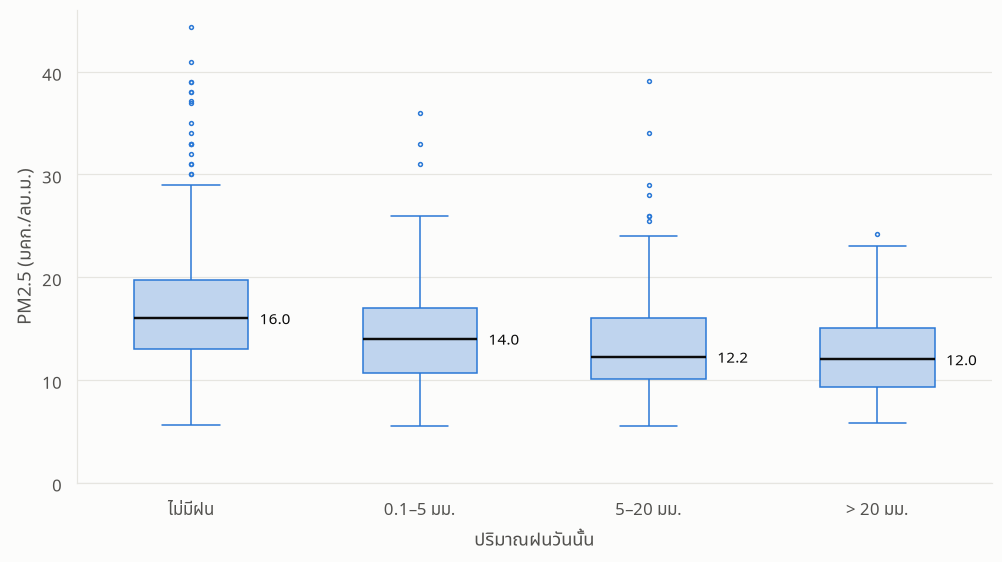

บันทึก: /home/gottagogoon/work/psu/pm-2.5_factors/graph/09_rain_boxplot.png


In [12]:
rain_stats = df.groupby("rain_bin", observed=False).pm25.agg(["mean", "median", "count"])
display(rain_stats.round(2))

fig, ax = plt.subplots(figsize=(9, 5), layout="constrained")
sns.boxplot(data=df, x="rain_bin", y="pm25", order=RAIN_BINS, color="#b7d3f6", width=0.5, linewidth=1,
            linecolor=SERIES[0], fliersize=2.5, medianprops={"color": INK, "lw": 1.6}, ax=ax)
for i, m in enumerate(rain_stats["median"]):
    ax.text(i + 0.3, m, f"{m:.1f}", va="center", ha="left", fontsize=10, color=INK)
ax.set(xlabel="ปริมาณฝนวันนั้น", ylabel=PM_LABEL, ylim=(0, 46))
ax.grid(axis="x", visible=False)
kw = stats.kruskal(*[g.pm25 for _, g in df.groupby("rain_bin", observed=True)])
print(f"Kruskal–Wallis (ปริมาณฝน): H = {kw.statistic:.1f}, p = {kw.pvalue:.1e}")
savefig(fig, "09_rain_boxplot.png")

,lag,r,p,n
0,0,-0.3018,0.0,1804
1,1,-0.3542,0.0,1795
2,2,-0.2884,0.0,1786
3,3,-0.2344,0.0,1777
4,4,-0.2014,0.0,1768
5,5,-0.1709,0.0,1759


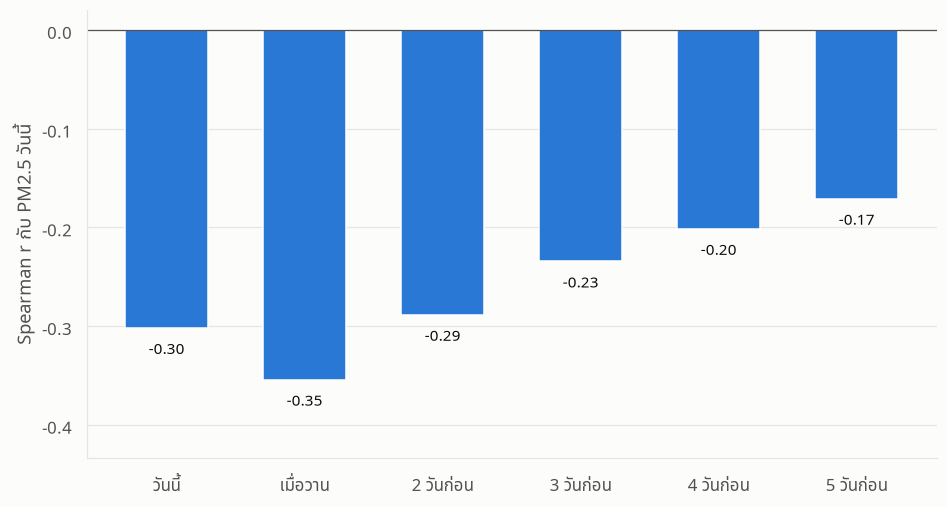

บันทึก: /home/gottagogoon/work/psu/pm-2.5_factors/graph/10_rain_lag.png


In [13]:
# ฝนย้อนหลังกี่วันยังสัมพันธ์กับฝุ่นวันนี้ (lag ใช้เฉพาะช่วงที่วันที่ต่อเนื่อง)
lag_rows = []
for lag in range(0, 6):
    ok = pd.Series(True, index=df.index)
    for k in range(lag):
        ok &= next_day.shift(k, fill_value=False)
    x = df.rain.shift(lag).where(ok)
    d = pd.DataFrame({"pm25": df.pm25, "x": x}).dropna()
    r, p = stats.spearmanr(d.pm25, d.x)
    lag_rows.append({"lag": lag, "r": r, "p": p, "n": len(d)})
lag_df = pd.DataFrame(lag_rows)
display(lag_df.round(4))

fig, ax = plt.subplots(figsize=(8.5, 4.5), layout="constrained")
ax.bar(lag_df.lag, lag_df.r, color=NEG, width=0.6)
for x, r in zip(lag_df.lag, lag_df.r):
    ax.text(x, r - 0.01, f"{r:.2f}", ha="center", va="top", fontsize=10, color=INK)
ax.axhline(0, color=INK2, lw=0.8)
ax.set_xticks(lag_df.lag, ["วันนี้", "เมื่อวาน", "2 วันก่อน", "3 วันก่อน", "4 วันก่อน", "5 วันก่อน"])
ax.set(ylabel="Spearman r กับ PM2.5 วันนี้", ylim=(lag_df.r.min() - 0.08, 0.02))
ax.grid(axis="x", visible=False)
savefig(fig, "10_rain_lag.png")

**อ่านกราฟ:** วันที่ไม่มีฝนมีฝุ่นมัธยฐาน 16.0 ส่วนวันที่ฝนเกิน 20 มม. มีมัธยฐาน 12.0

ฝนเมื่อวานสัมพันธ์กับฝุ่นวันนี้มากกว่าฝนวันนี้ ซึ่งสอดคล้องกับที่ฝนชะฝุ่นออกจากอากาศแล้วส่งผลต่อเนื่องไปวันรุ่งขึ้น ผลนี้ค่อย ๆ จางลงจนเหลือ −0.17 เมื่อผ่านไป 5 วัน

### 4.3 ทิศลมและฝนร่วมกัน

ทิศลมกับฝนไม่เป็นอิสระต่อกัน (ลมบางทิศมาพร้อมฝน) จึงดูสองปัจจัยพร้อมกันในตารางเดียว ช่องที่มีน้อยกว่า 10 วันถูกเว้นว่างไว้

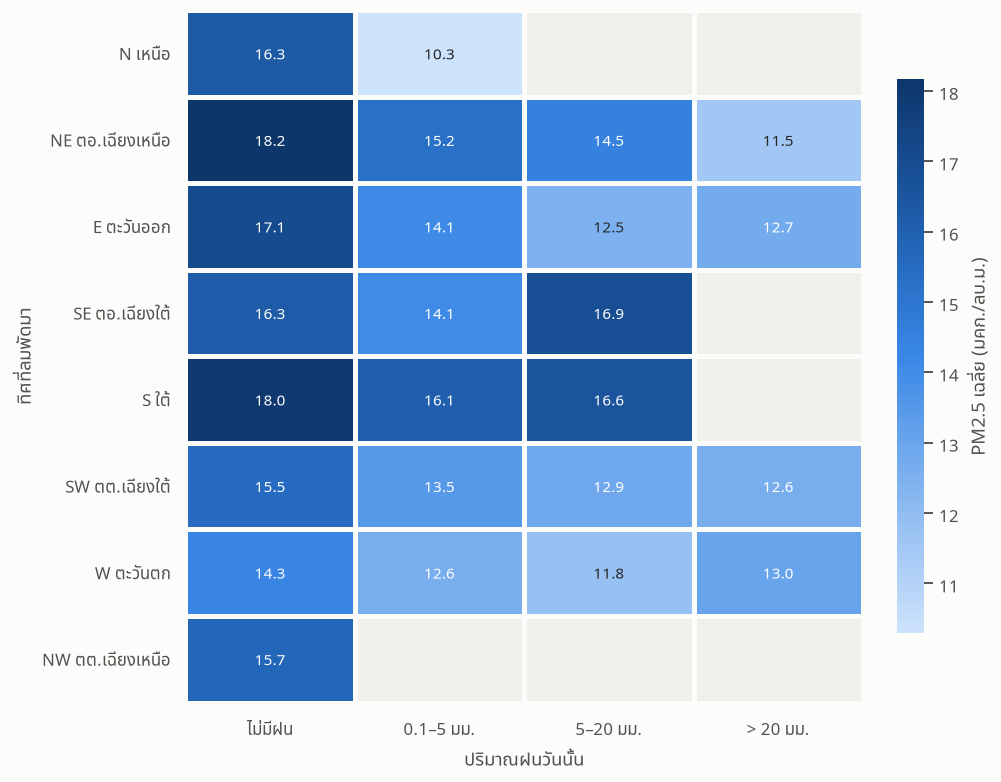

บันทึก: /home/gottagogoon/work/psu/pm-2.5_factors/graph/11_wind_rain_heatmap.png


In [14]:
joint = df.pivot_table(index="wind_sector", columns="rain_bin", values="pm25", aggfunc="mean", observed=False)
joint_n = df.pivot_table(index="wind_sector", columns="rain_bin", values="pm25", aggfunc="count", observed=False)
show = joint.where(joint_n >= 10)
annot = show.round(1).astype(str).where(show.notna(), "")

fig, ax = plt.subplots(figsize=(9, 7), layout="constrained")
sns.heatmap(show, annot=annot, fmt="", annot_kws={"fontsize": 10}, cmap=SEQ_CMAP, linewidths=2, linecolor=SURFACE,
            cbar_kws={"label": "PM2.5 เฉลี่ย (มคก./ลบ.ม.)", "shrink": 0.8}, ax=ax)
ax.set_facecolor("#f0efec"); ax.grid(False)
ax.set_yticks(np.arange(len(SECTORS)) + 0.5, [f"{s} {SECTOR_TH[s]}" for s in SECTORS], rotation=0)
ax.set(xlabel="ปริมาณฝนวันนั้น", ylabel="ทิศที่ลมพัดมา")
savefig(fig, "11_wind_rain_heatmap.png")

**อ่านกราฟ:** ไม่ว่าลมจะมาจากทิศไหน ฝนตกมากขึ้นฝุ่นก็ลดลงเกือบทุกแถว
- ลมตะวันออก: 17.1 → 12.5–12.7
- ลมตะวันออกเฉียงเหนือ: 18.2 → 11.5

ค่าสูงสุดเกิดเมื่อ **ลมมาจากตะวันออกเฉียงเหนือหรือใต้ และไม่มีฝน** ผลของฝนจึงไม่ได้เป็นแค่เงาของทิศลม

## 5. วัตถุประสงค์ 3: วันทำงาน vs วันหยุด และฤดูมรสุม vs ช่วงปกติ

ใช้ **Mann–Whitney U** เทียบสองกลุ่ม และ **Kruskal–Wallis** เทียบหลายกลุ่ม เพราะ PM2.5 เบ้ขวา ไม่ใช่การแจกแจงปกติ

### 5.1 ประเภทวัน

,mean,median,std,count
day_type,,,,
วันทำงานปกติ,14.82,14.00,5.14,1179
วันหยุดสุดสัปดาห์,14.91,14.35,5.23,490
วันหยุดราชการ/นักขัตฤกษ์,15.99,15.00,6.31,135


Kruskal–Wallis 3 กลุ่ม: H=3.59, p=0.166
วันทำงาน vs วันหยุดสุดสัปดาห์: U=285115, p=0.677
วันทำงาน vs วันหยุดราชการ: U=71698, p=0.059


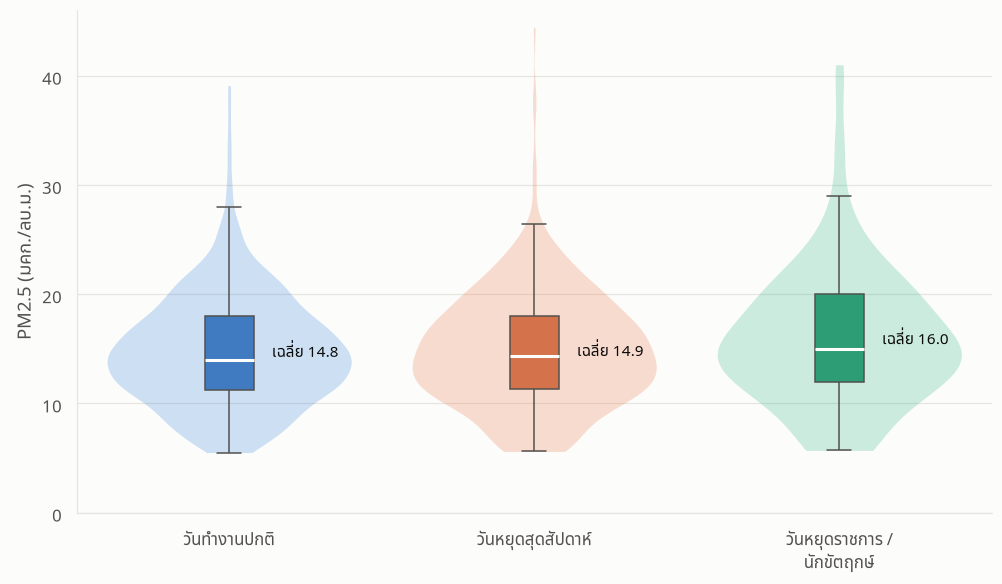

บันทึก: /home/gottagogoon/work/psu/pm-2.5_factors/graph/12_day_type_violin.png


In [15]:
day_stats = df.groupby("day_type", observed=False).pm25.agg(["mean", "median", "std", "count"])
display(day_stats.round(2))
kw_day = stats.kruskal(*[g.pm25 for _, g in df.groupby("day_type", observed=True)])
work = df.loc[df.day_type.eq("วันทำงานปกติ"), "pm25"]
weekend = df.loc[df.day_type.eq("วันหยุดสุดสัปดาห์"), "pm25"]
holiday = df.loc[df.day_type.eq("วันหยุดราชการ/นักขัตฤกษ์"), "pm25"]
mw_we = stats.mannwhitneyu(work, weekend)
mw_ho = stats.mannwhitneyu(work, holiday)
print(f"Kruskal–Wallis 3 กลุ่ม: H={kw_day.statistic:.2f}, p={kw_day.pvalue:.3f}")
print(f"วันทำงาน vs วันหยุดสุดสัปดาห์: U={mw_we.statistic:.0f}, p={mw_we.pvalue:.3f}")
print(f"วันทำงาน vs วันหยุดราชการ: U={mw_ho.statistic:.0f}, p={mw_ho.pvalue:.3f}")

fig, ax = plt.subplots(figsize=(9, 5.2), layout="constrained")
for i, dt in enumerate(DAYTYPE_ORDER):
    parts = ax.violinplot(df.loc[df.day_type.eq(dt), "pm25"], positions=[i], widths=0.8, showextrema=False)
    for body in parts["bodies"]:
        body.set(facecolor=DAYTYPE_COLORS[dt], alpha=0.22, lw=0)
sns.boxplot(data=df, x="day_type", y="pm25", order=DAYTYPE_ORDER, hue="day_type", hue_order=DAYTYPE_ORDER,
            palette=DAYTYPE_COLORS, dodge=False, width=0.16, linewidth=1, linecolor=INK2, showfliers=False,
            medianprops={"color": SURFACE, "lw": 2}, legend=False, ax=ax)
for i, (mean, n) in enumerate(zip(day_stats["mean"], day_stats["count"])):
    ax.text(i + 0.14, mean, f"เฉลี่ย {mean:.1f}", va="center", ha="left", fontsize=10, color=INK)
ax.set_xticks(range(3), ["วันทำงานปกติ", "วันหยุดสุดสัปดาห์", "วันหยุดราชการ /\nนักขัตฤกษ์"])
ax.set(xlabel="", ylabel=PM_LABEL, ylim=(0, 46))
ax.grid(axis="x", visible=False)
savefig(fig, "12_day_type_violin.png")

day_type,วันทำงานปกติ,วันหยุดสุดสัปดาห์,วันหยุดราชการ/นักขัตฤกษ์
season,,,
มรสุม ตอ.น.,347,143,36
ฤดูแล้ง,288,120,34
เปลี่ยนมรสุม,193,80,32
หมอกควันข้ามแดน,351,147,33


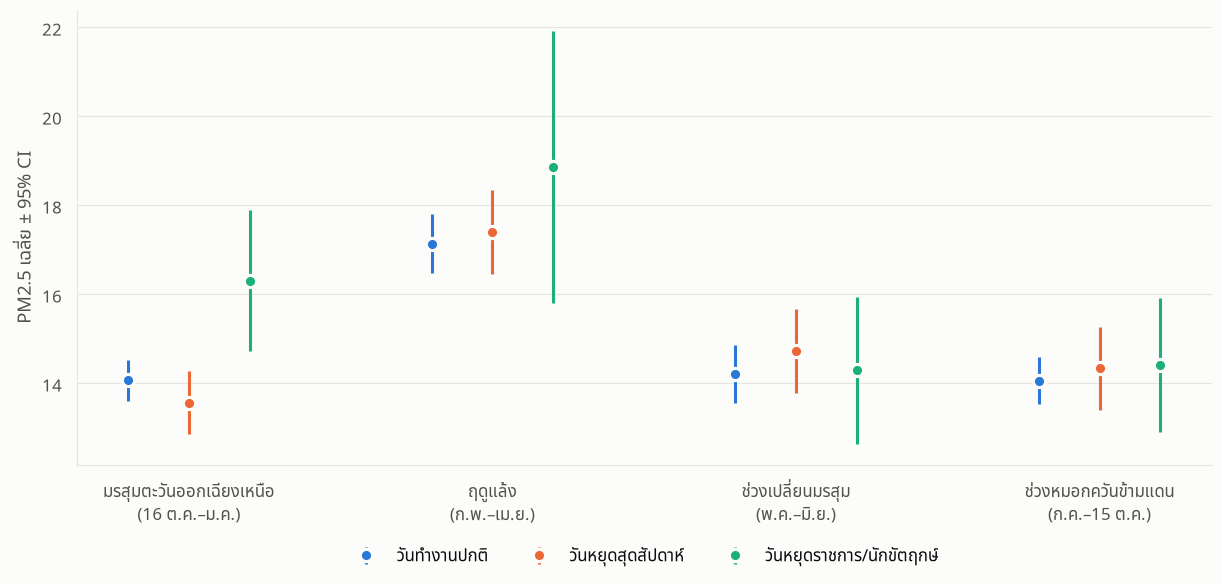

บันทึก: /home/gottagogoon/work/psu/pm-2.5_factors/graph/13_day_type_by_season.png


In [16]:
# วันหยุดราชการไม่ได้กระจายเท่ากันทุกฤดู จึงเทียบประเภทวันภายในฤดูเดียวกัน
ci = df.groupby(["season", "day_type"], observed=False).pm25.agg(["mean", "sem", "count"]).reset_index()
ci["ci95"] = 1.96 * ci["sem"]
display(pd.crosstab(df.season, df.day_type).rename(index=SEASON_SHORT))

fig, ax = plt.subplots(figsize=(11, 5.2), layout="constrained")
offsets = dict(zip(DAYTYPE_ORDER, [-0.2, 0, 0.2]))
for dt in DAYTYPE_ORDER:
    sub = ci[ci.day_type.eq(dt)]
    x = np.arange(len(SEASON_ORDER)) + offsets[dt]
    ax.errorbar(x, sub["mean"], yerr=sub["ci95"], fmt="o", ms=8, color=DAYTYPE_COLORS[dt], mec=SURFACE, mew=2,
                elinewidth=2, capsize=0, label=dt)
ax.set_xticks(range(len(SEASON_ORDER)), [SEASON_TH[s] for s in SEASON_ORDER])
ax.set(ylabel="PM2.5 เฉลี่ย ± 95% CI", xlabel="")
ax.grid(axis="x", visible=False)
ax.legend(loc="upper center", ncol=3, bbox_to_anchor=(0.5, -0.14))
savefig(fig, "13_day_type_by_season.png")

**อ่านกราฟ:** ฝุ่นในวันทำงาน (14.8) กับวันหยุดสุดสัปดาห์ (14.9) **ไม่ต่างกัน** (p = 0.68)

วันหยุดราชการสูงกว่าเล็กน้อย (16.0, p = 0.06 ยังไม่ถึงเกณฑ์ 0.05) และสูงเด่นเฉพาะในมรสุมกับฤดูแล้ง เหตุผลที่น่าจะเป็นคือวันหยุดยาวตรงกับเดือนที่ฝุ่นสูงอยู่แล้ว
- วันหยุดในฤดูแล้ง 27 จาก 34 วันอยู่ในเดือนเมษายน (สงกรานต์) ซึ่งเป็นเดือนที่ฝุ่นสูงสุด
- วันหยุดปีใหม่อยู่ในเดือนมกราคม ซึ่งฝุ่นก็สูงเช่นกัน

จึงไม่ได้เป็นผลจากการหยุดงานโดยตรง และแต่ละกลุ่มมีวันหยุดเพียง 32–36 วัน ช่วงความเชื่อมั่นจึงกว้าง

### 5.2 ฤดูกาล และฤดูมรสุม vs ช่วงปกติ

,pm25,rain,wind_max,humidity,วันที่ฝนตก_%,PM2.5_mean
season,,,,,,
มรสุม ตอ.น.,13.85,0.8,17.3,83.44,62.17,14.06
ฤดูแล้ง,17.00,0.0,17.1,76.88,30.09,17.32
เปลี่ยนมรสุม,14.20,0.2,13.6,79.38,52.13,14.34
หมอกควันข้ามแดน,13.50,0.2,14.6,79.88,53.48,14.14


Kruskal–Wallis 4 ฤดู: H=110.6, p=8.2e-24
มรสุม vs ช่วงปกติ: มัธยฐาน 13.9 vs 15.0; เฉลี่ย 14.06 vs 15.29; U=294058, p=2.9e-05


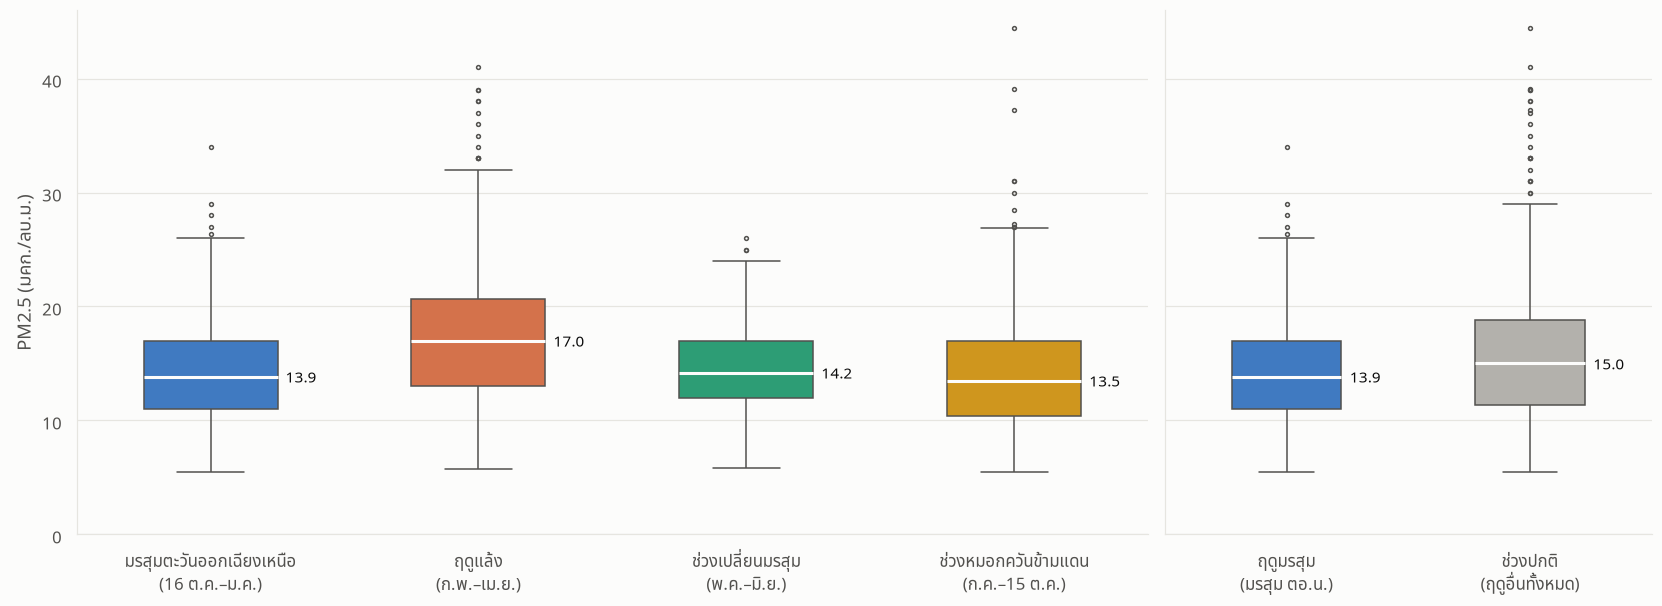

บันทึก: /home/gottagogoon/work/psu/pm-2.5_factors/graph/14_season_boxplot.png


In [17]:
season_stats = df.groupby("season", observed=False)[["pm25", "rain", "wind_max", "humidity"]].median()
season_stats["วันที่ฝนตก_%"] = df.groupby("season", observed=False).rain.apply(lambda s: 100 * (s > 0).mean())
season_stats["PM2.5_mean"] = df.groupby("season", observed=False).pm25.mean()
display(season_stats.rename(index=SEASON_SHORT).round(2))

kw_season = stats.kruskal(*[g.pm25 for _, g in df.groupby("season", observed=True)])
mon = df.loc[df.monsoon.eq("ฤดูมรสุม"), "pm25"]; nor = df.loc[df.monsoon.eq("ช่วงปกติ"), "pm25"]
mw_mon = stats.mannwhitneyu(mon, nor)
print(f"Kruskal–Wallis 4 ฤดู: H={kw_season.statistic:.1f}, p={kw_season.pvalue:.1e}")
print(f"มรสุม vs ช่วงปกติ: มัธยฐาน {mon.median():.1f} vs {nor.median():.1f}; เฉลี่ย {mon.mean():.2f} vs {nor.mean():.2f}; U={mw_mon.statistic:.0f}, p={mw_mon.pvalue:.1e}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.4), width_ratios=[2.2, 1], sharey=True, layout="constrained")
sns.boxplot(data=df, x="season", y="pm25", order=SEASON_ORDER, hue="season", hue_order=SEASON_ORDER, palette=SEASON_COLORS, dodge=False,
            width=0.5, linewidth=1, linecolor=INK2, fliersize=2.5, medianprops={"color": SURFACE, "lw": 2}, legend=False, ax=ax1)
for i, m in enumerate(df.groupby("season", observed=False).pm25.median()):
    ax1.text(i + 0.28, m, f"{m:.1f}", va="center", ha="left", fontsize=10, color=INK)
ax1.set_xticks(range(4), [SEASON_TH[s] for s in SEASON_ORDER])
ax1.set(xlabel="", ylabel=PM_LABEL, ylim=(0, 46))

sns.boxplot(data=df, x="monsoon", y="pm25", order=["ฤดูมรสุม", "ช่วงปกติ"], hue="monsoon", hue_order=["ฤดูมรสุม", "ช่วงปกติ"],
            palette={"ฤดูมรสุม": SERIES[0], "ช่วงปกติ": "#b4b2ab"}, dodge=False, width=0.45, linewidth=1, linecolor=INK2, fliersize=2.5,
            medianprops={"color": SURFACE, "lw": 2}, legend=False, ax=ax2)
for i, m in enumerate([mon.median(), nor.median()]):
    ax2.text(i + 0.26, m, f"{m:.1f}", va="center", ha="left", fontsize=10, color=INK)
ax2.set_xticks(range(2), ["ฤดูมรสุม\n(มรสุม ตอ.น.)", "ช่วงปกติ\n(ฤดูอื่นทั้งหมด)"])
ax2.set(xlabel="")
for ax in (ax1, ax2):
    ax.grid(axis="x", visible=False)
savefig(fig, "14_season_boxplot.png")

**อ่านกราฟ:**
- **ฤดูแล้ง** ฝุ่นสูงที่สุด (มัธยฐาน 17.0) ฤดูอื่นอยู่ที่ประมาณ 13.5–14.2
- **ฤดูมรสุม** ฝุ่นต่ำกว่าช่วงปกติอย่างมีนัยสำคัญ (มัธยฐาน 13.9 เทียบกับ 15.0, p < 0.001) ฤดูนี้มีวันฝนตก 62% และความชื้นมัธยฐาน 83%
- **ข้อควรระวัง:** ความต่างส่วนใหญ่มาจากฤดูแล้งที่อยู่ในกลุ่ม "ช่วงปกติ" ถ้าเทียบมรสุมกับช่วงเปลี่ยนมรสุมหรือช่วงหมอกควันโดยตรง ค่าใกล้กันมาก

aqi_level,ดีมาก,ดี,ปานกลาง,เริ่มมีผลกระทบต่อสุขภาพ
season,,,,
มรสุม ตอ.น.,64.3,34.0,1.7,0.0
ฤดูแล้ง,40.0,52.7,6.1,1.1
เปลี่ยนมรสุม,61.3,38.4,0.3,0.0
หมอกควันข้ามแดน,62.0,35.4,2.3,0.4


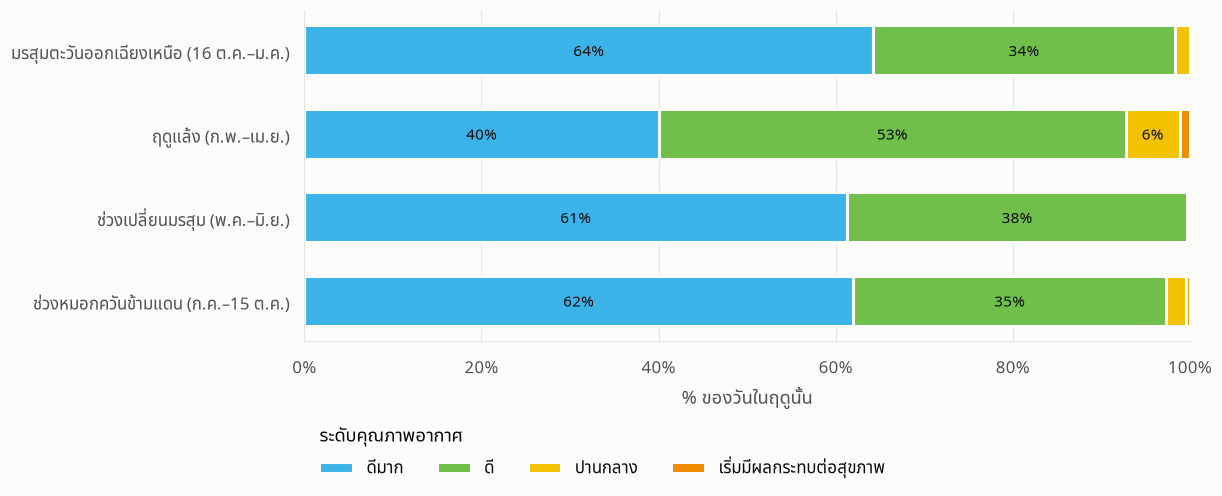

บันทึก: /home/gottagogoon/work/psu/pm-2.5_factors/graph/15_aqi_level_by_season.png


In [18]:
# สัดส่วนวันตามระดับคุณภาพอากาศในแต่ละฤดู (100% stacked bar)
aqi_share = pd.crosstab(df.season, df.aqi_level, normalize="index").reindex(index=SEASON_ORDER, columns=AQI_ORDER) * 100
display(aqi_share.rename(index=SEASON_SHORT).round(1))

fig, ax = plt.subplots(figsize=(11, 4.4), layout="constrained")
left = np.zeros(len(SEASON_ORDER))
ylabels = [SEASON_TH[s].replace("\n", " ") for s in SEASON_ORDER]
for lvl in AQI_ORDER:
    vals = aqi_share[lvl].to_numpy()
    ax.barh(ylabels, vals, left=left, color=AQI_COLORS[lvl], height=0.6, edgecolor=SURFACE, lw=2, label=lvl)
    for y, (l, v) in enumerate(zip(left, vals)):
        if v >= 6:
            ax.text(l + v / 2, y, f"{v:.0f}%", ha="center", va="center", fontsize=10, color=INK)
    left += vals
ax.invert_yaxis()
ax.set(xlim=(0, 100), xlabel="% ของวันในฤดูนั้น")
ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0f}%")
ax.grid(axis="y", visible=False)
ax.legend(title="ระดับคุณภาพอากาศ", ncol=4, loc="upper left", bbox_to_anchor=(0, -0.2), alignment="left")
savefig(fig, "15_aqi_level_by_season.png")

wind_sector,N,NE,E,SE,S,SW,W,NW
season,,,,,,,,
มรสุม ตอ.น.,4.4,25.7,52.3,1.7,1.9,6.3,4.4,3.4
ฤดูแล้ง,0.7,5.0,77.1,3.2,1.8,8.4,3.2,0.7
เปลี่ยนมรสุม,2.3,2.3,10.2,7.2,12.8,54.1,10.8,0.3
หมอกควันข้ามแดน,0.8,1.1,4.0,5.3,6.8,62.3,17.9,1.9


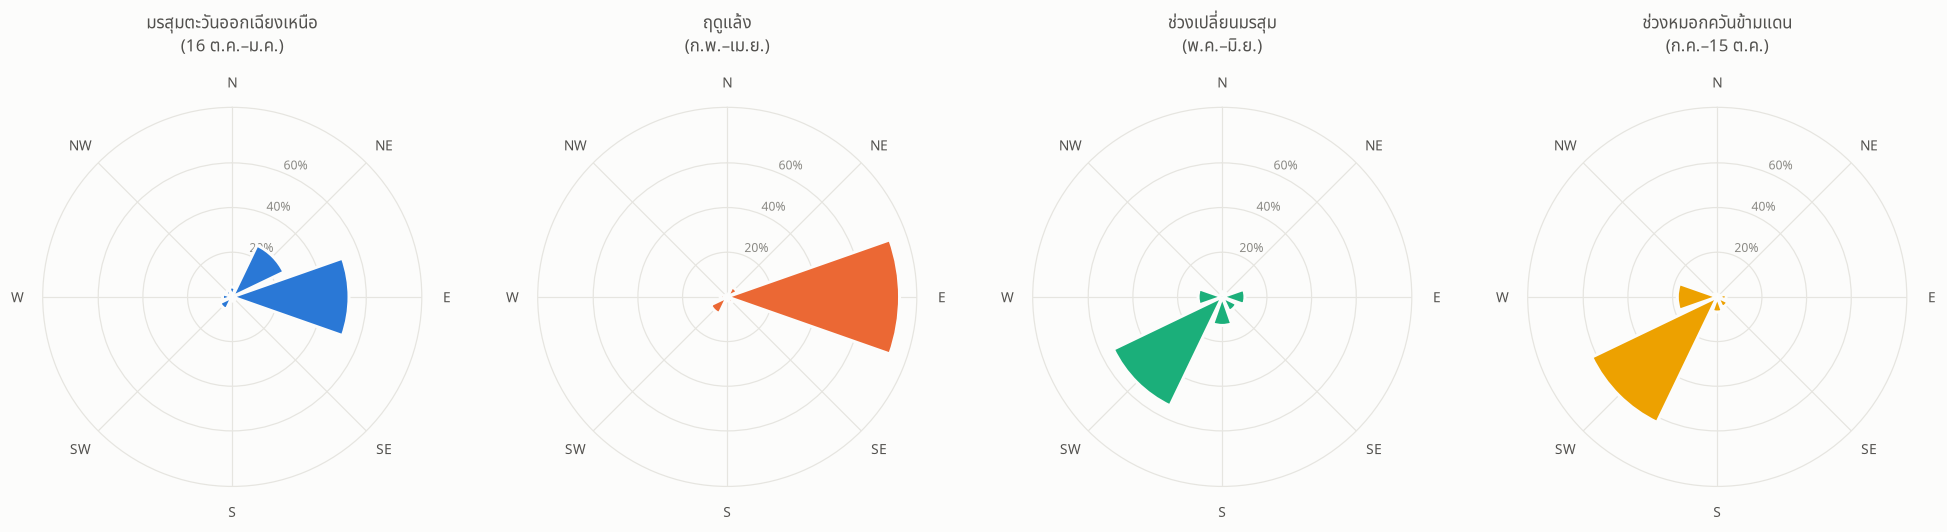

บันทึก: /home/gottagogoon/work/psu/pm-2.5_factors/graph/16_wind_direction_by_season.png


In [19]:
# ทิศลมในแต่ละฤดู — อธิบายว่าทำไมฝุ่นแต่ละฤดูต่างกัน
wind_season = (pd.crosstab(df.season, df.wind_sector, normalize="index") * 100).reindex(index=SEASON_ORDER, columns=SECTORS)
display(wind_season.rename(index=SEASON_SHORT).round(1))

fig, axes = plt.subplots(1, 4, figsize=(18, 5.2), subplot_kw={"projection": "polar"}, layout="constrained")
fig.get_layout_engine().set(w_pad=0.25)
rmax = wind_season.to_numpy().max() * 1.1
for ax, s in zip(axes, SEASON_ORDER):
    ax.bar(theta, wind_season.loc[s].to_numpy(), width=width, color=SEASON_COLORS[s], edgecolor=SURFACE, lw=2)
    ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
    ax.set_xticks(theta, SECTORS, fontsize=9)
    ax.set_ylim(0, rmax); ax.set_yticks([20, 40, 60]); ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0f}%")
    ax.tick_params(axis="y", labelsize=8, colors=MUTED); ax.set_rlabel_position(22.5)
    ax.grid(color=GRID, lw=0.8); ax.spines["polar"].set_color(GRID)
    ax.set_title(SEASON_TH[s], loc="center", fontsize=11, pad=14, fontweight="normal", color=INK2)
savefig(fig, "16_wind_direction_by_season.png")

**อ่านกราฟ:** ฤดูแล้งมีลมตะวันออก 77% และมีวันฝนตกเพียง 30% จึงเป็นช่วงที่ "ฝนน้อย + ลมตะวันออก" มาพร้อมกัน นี่เป็นเหตุผลที่ลมตะวันออกดูสัมพันธ์กับฝุ่นสูงในกราฟ 06–08

ช่วงเปลี่ยนมรสุมและช่วงหมอกควันมีลมตะวันตกเฉียงใต้เป็นหลัก (54–62%) ช่วงหมอกควันมีค่าเฉลี่ยไม่สูง แต่มีวันพีกรุนแรง เช่น 29–30 ก.ย. 2023

## 6. สรุปรวม: ปัจจัยไหนสำคัญที่สุดเมื่อดูพร้อมกัน

ใช้ Random Forest ทำนาย PM2.5 จากทุกปัจจัยพร้อมกัน แล้ววัด **permutation importance** (ถ้าสลับค่าปัจจัยนั้นแบบสุ่ม ค่าคลาดเคลื่อนเพิ่มขึ้นเท่าไร)

- ใส่ **ปี** เป็นตัวแปรด้วย เพราะฝุ่นลดลงชัดในปี 2024–2025 จากสาเหตุที่ไม่อยู่ในข้อมูลนี้ ถ้าไม่ใส่ โมเดลจะโยนแนวโน้มนี้ไปให้ปัจจัยอื่น
- ประเมินแบบ cross-validation 5 fold โดย **แบ่งเป็นก้อนรายเดือน** (วันในเดือนเดียวกันอยู่ fold เดียวกัน) เพื่อไม่ให้วันที่ติดกันรั่วข้าม train/test
- ไม่ใส่ลมกระโชกและฝนสะสม 3 วัน เพราะซ้ำกับลมสูงสุดและฝนวันนี้/เมื่อวาน ความสำคัญจะถูกแบ่งกันจนอ่านผิด
- importance นี้เป็นความสำคัญเชิงพยากรณ์ ไม่ใช่เหตุและผล

CV 5 fold (แบ่งตามเดือน): R² = 0.316, MAE = 3.25 มคก./ลบ.ม.; แต่ละ fold R² = [0.25, 0.4, 0.27, 0.43, 0.23]


,feature,importance,std
9,ปี (แนวโน้มระยะยาว),0.844,0.223
3,ความชื้นสัมพัทธ์,0.212,0.101
1,ฝนเมื่อวาน,0.175,0.051
2,ความเร็วลมสูงสุด,0.084,0.048
4,ทิศลม ตะวันออก–ตะวันตก,0.080,0.100
0,ฝนวันนี้,0.050,0.026
8,ฤดูกาล,0.038,0.048
5,ทิศลม เหนือ–ใต้,0.033,0.057
7,วันหยุดราชการ,0.002,0.003
6,วันหยุดสุดสัปดาห์,0.000,0.002


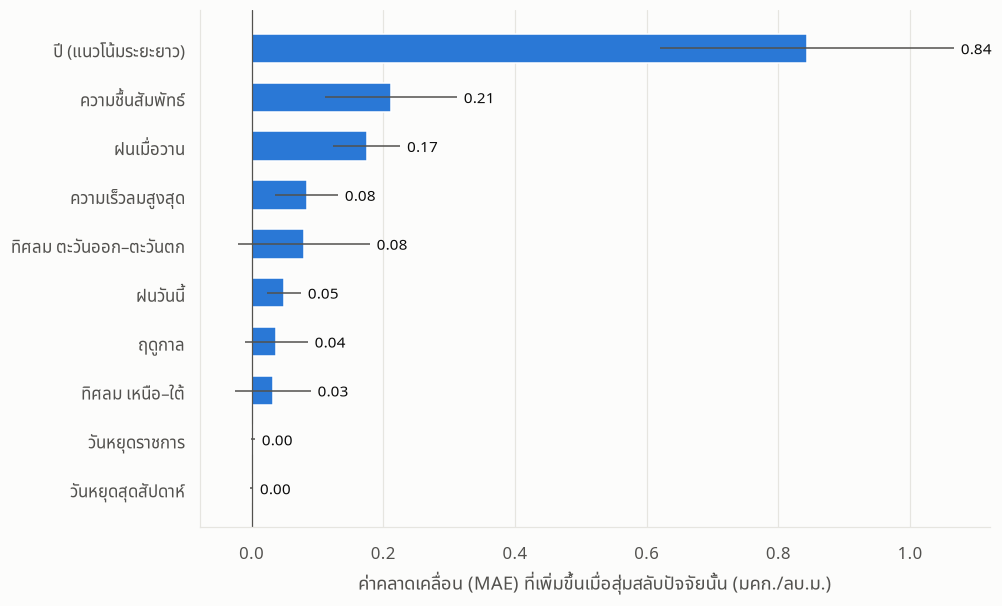

บันทึก: /home/gottagogoon/work/psu/pm-2.5_factors/graph/17_permutation_importance.png


In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import GroupKFold

FEATURES = {
    "rain": "ฝนวันนี้", "rain_lag1": "ฝนเมื่อวาน", "wind_max": "ความเร็วลมสูงสุด", "humidity": "ความชื้นสัมพัทธ์",
    "wind_sin": "ทิศลม ตะวันออก–ตะวันตก", "wind_cos": "ทิศลม เหนือ–ใต้",
    "is_weekend": "วันหยุดสุดสัปดาห์", "is_holiday": "วันหยุดราชการ", "season_code": "ฤดูกาล", "year": "ปี (แนวโน้มระยะยาว)",
}
model_df = df.assign(
    is_weekend=df.day_type.eq("วันหยุดสุดสัปดาห์").astype(int),
    is_holiday=df.day_type.eq("วันหยุดราชการ/นักขัตฤกษ์").astype(int),
    season_code=df.season.cat.codes,
).dropna(subset=list(FEATURES)).reset_index(drop=True)
X, y = model_df[list(FEATURES)], model_df.pm25
groups = model_df.date.dt.to_period("M").astype(str)

fold_scores, fold_imps = [], []
for train_idx, test_idx in GroupKFold(n_splits=5, shuffle=True, random_state=42).split(X, y, groups):
    rf = RandomForestRegressor(n_estimators=400, min_samples_leaf=5, max_features=0.6, random_state=42, n_jobs=-1)
    rf.fit(X.iloc[train_idx], y.iloc[train_idx])
    pred = rf.predict(X.iloc[test_idx])
    fold_scores.append((r2_score(y.iloc[test_idx], pred), mean_absolute_error(y.iloc[test_idx], pred)))
    perm = permutation_importance(rf, X.iloc[test_idx], y.iloc[test_idx], n_repeats=10, random_state=42, n_jobs=-1,
                                  scoring="neg_mean_absolute_error")
    fold_imps.append(perm.importances_mean)
r2, mae = np.mean(fold_scores, axis=0)
print(f"CV 5 fold (แบ่งตามเดือน): R² = {r2:.3f}, MAE = {mae:.2f} มคก./ลบ.ม.; แต่ละ fold R² =", [round(a, 2) for a, _ in fold_scores])

fold_imps = np.array(fold_imps)
imp = pd.DataFrame({"feature": list(FEATURES.values()), "importance": fold_imps.mean(axis=0), "std": fold_imps.std(axis=0)}).sort_values("importance")
display(imp.iloc[::-1].round(3))

fig, ax = plt.subplots(figsize=(9, 5.4), layout="constrained")
ax.barh(imp.feature, imp.importance, xerr=imp["std"], color=SERIES[0], height=0.6, error_kw={"ecolor": INK2, "lw": 1})
for yy, v, sd in zip(range(len(imp)), imp.importance, imp["std"]):
    ax.text(max(v + sd, 0) + 0.01, yy, f"{v:.2f}", va="center", fontsize=10, color=INK)
ax.axvline(0, color=INK2, lw=0.8)
ax.set(xlabel="ค่าคลาดเคลื่อน (MAE) ที่เพิ่มขึ้นเมื่อสุ่มสลับปัจจัยนั้น (มคก./ลบ.ม.)")
ax.grid(axis="y", visible=False)
savefig(fig, "17_permutation_importance.png")

**อ่านกราฟ:**
- **ปี (แนวโน้มระยะยาว)** สำคัญที่สุด ฝุ่นที่ลดลงในปี 2024–2025 จึงอธิบายด้วยสภาพอากาศในข้อมูลนี้ไม่ได้ น่าจะมาจากปัจจัยภายนอก เช่น แหล่งกำเนิดหรือหมอกควันข้ามแดนที่ลดลง
- ปัจจัยสภาพอากาศที่สำคัญรองลงมาคือความชื้นและฝนเมื่อวาน ส่วนประเภทวันแทบไม่มีผล
- โมเดลอธิบายความแปรปรวนได้ประมาณ 32% (R² = 0.32) ที่เหลือมาจากปัจจัยที่ไม่อยู่ในข้อมูล

## 7. ตารางสรุปตัวเลขหลัก

In [21]:
def cmp_row(name, a, b, test):
    return {"การเปรียบเทียบ": name, "มัธยฐาน A": a.median(), "มัธยฐาน B": b.median(),
            "เฉลี่ย A": a.mean(), "เฉลี่ย B": b.mean(), "p-value": test.pvalue}

rain_yes, rain_no = df.loc[df.rain > 0, "pm25"], df.loc[df.rain == 0, "pm25"]
summary = pd.DataFrame([
    cmp_row("A = ฝนตก, B = ไม่มีฝน", rain_yes, rain_no, stats.mannwhitneyu(rain_yes, rain_no)),
    cmp_row("A = วันทำงาน, B = วันหยุดสุดสัปดาห์", work, weekend, mw_we),
    cmp_row("A = วันทำงาน, B = วันหยุดราชการ", work, holiday, mw_ho),
    cmp_row("A = ฤดูมรสุม, B = ช่วงปกติ", mon, nor, mw_mon),
]).round(3)
display(summary)
display(cor_table.drop(columns="col").sort_values("Spearman r").round(3))

,การเปรียบเทียบ,มัธยฐาน A,มัธยฐาน B,เฉลี่ย A,เฉลี่ย B,p-value
0,"A = ฝนตก, B = ไม่มีฝน",13.00,16.00,13.428,16.440,0.000
1,"A = วันทำงาน, B = วันหยุดสุดสัปดาห์",14.00,14.35,14.822,14.906,0.677
2,"A = วันทำงาน, B = วันหยุดราชการ",14.00,15.00,14.822,15.991,0.059
3,"A = ฤดูมรสุม, B = ช่วงปกติ",13.85,15.00,14.063,15.290,0.000


,ปัจจัย,Spearman r,p-value,n
7,ฝนสะสม 3 วัน,-0.393,0.000,1786
6,ฝนเมื่อวาน,-0.354,0.000,1795
5,ฝนวันนี้,-0.302,0.000,1804
4,ความชื้นสัมพัทธ์,-0.269,0.000,1804
2,ความเร็วลมสูงสุด,-0.094,0.000,1804
1,ลมกระโชก,-0.064,0.007,1804
0,ทิศลม (+ = มาจากเหนือ),0.034,0.155,1804
3,ทิศลม (+ = มาจากตะวันออก),0.177,0.000,1804


## 8. สรุปผลตามวัตถุประสงค์

**1. ปัจจัยที่สัมพันธ์กับ PM2.5**
- **ฝน** สัมพันธ์มากที่สุด (Spearman −0.30 ถึง −0.39) ตามด้วยความชื้น (−0.27)
- **ความเร็วลม** แทบไม่สัมพันธ์ ยกเว้นวันที่ลมอ่อนมาก
- ปัจจัยสภาพอากาศรวมกันอธิบายฝุ่นรายวันได้ประมาณหนึ่งในสาม ส่วนแนวโน้มลดลงระยะยาวมาจากปัจจัยนอกข้อมูลนี้

**2. ทิศลม ฝน และ PM2.5 รายวัน**
- **ฝน:** วันที่ฝนตกฝุ่นต่ำกว่าวันไม่มีฝนชัดเจน (มัธยฐาน 13.0 เทียบกับ 16.0) ฝนเมื่อวานส่งผลมากกว่าฝนวันนี้ และผลลากไปหลายวัน
- **ทิศลม:** ลมจากฝั่งตะวันออก ตะวันออกเฉียงเหนือ และใต้ มาพร้อมฝุ่นสูงกว่าลมฝั่งตะวันตก แต่ส่วนหนึ่งเป็นเพราะลมตะวันออกคือลมของฤดูแล้ง
- ฝนลดฝุ่นได้ในทุกทิศลม

**3. การเปรียบเทียบ**
- **วันทำงาน vs วันหยุดสุดสัปดาห์:** ไม่ต่างกัน (14.8 กับ 14.9, p = 0.68)
- **วันหยุดราชการ:** สูงกว่าเล็กน้อยแต่ไม่มีนัยสำคัญ และน่าจะเป็นผลของเดือนที่วันหยุดตรงกัน (สงกรานต์, ปีใหม่)
- **ฤดูมรสุม vs ช่วงปกติ:** มรสุมฝุ่นต่ำกว่า (13.9 กับ 15.0, p < 0.001) โดยความต่างมาจากฤดูแล้งเป็นหลัก ฤดูแล้งมีฝุ่นสูงสุดของปี (17.0) และมีสัดส่วนวันคุณภาพอากาศ "ดีมาก" เพียง 40%

**ข้อจำกัด**
- ทั้งหมดนี้เป็นความสัมพันธ์ ไม่ใช่เหตุและผล
- ค่าฝุ่นของวันที่ติดกันไม่อิสระต่อกัน ค่า p-value จึงดูดีกว่าความจริง
- ข้อมูลไม่มีตัวแปรแหล่งกำเนิด เช่น จุดความร้อน (hotspot) หรือปริมาณจราจร